# Hardware Efficiency Analysis of Soft-Prompt PEFT

This notebook contains the analysis of our training and inference experiments. We compare five fine-tuning methods (full fine-tune, LoRA, prefix-tune, prompt-tune, p-tune) across four Pythia model sizes (70M, 160M, 410M, 1B) on two GPUs: an NVIDIA A100 40GB (CUDA) and an AMD RX 9060 XT 16GB (ROCm).

Input files (uploaded to Colab):
- `ptperf-cuda.csv` and `ptperf-rocm.csv`: per-run final metrics exported from MLflow.
- `mlflow-cuda.db` and `mlflow-rocm.db`: full MLflow stores containing step-level training loss.

## 1. Setup and data loading

In [ ]:
import sqlite3

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110

MODEL_ORDER = [
    "EleutherAI/pythia-70m",
    "EleutherAI/pythia-160m",
    "EleutherAI/pythia-410m",
    "EleutherAI/pythia-1b",
]
MODEL_SHORT = {
    "EleutherAI/pythia-70m": "70M",
    "EleutherAI/pythia-160m": "160M",
    "EleutherAI/pythia-410m": "410M",
    "EleutherAI/pythia-1b": "1B",
}
METHOD_ORDER = ["fine-tune", "lora", "prefix-tune", "prompt-tune", "p-tune"]
METHOD_PALETTE = {
    "fine-tune": "#d62728",
    "lora": "#1f77b4",
    "prefix-tune": "#2ca02c",
    "prompt-tune": "#ff7f0e",
    "p-tune": "#9467bd",
}
METHOD_LABELS = {
    "fine-tune": "Full fine-tune",
    "lora": "LoRA",
    "prefix-tune": "Prefix tuning",
    "prompt-tune": "Prompt tuning",
    "p-tune": "P-tuning",
}

In [74]:
def load(fname: str, hardware: str) -> pd.DataFrame:
    df = pd.read_csv(fname)
    df["hardware"] = hardware
    df["model_short"] = df["model"].map(MODEL_SHORT)
    df["vram_mb"] = df["train.allocated_bytes.all.peak"] / 1024**2
    df["vram_reserved_mb"] = df["train.reserved_bytes.all.peak"] / 1024**2
    df["inf_vram_mb"] = df["inference.allocated_bytes.all.peak"] / 1024**2
    df["trainable_pct"] = df["trainable_parameters"] / df["total_parameters"] * 100
    df["flops_t"] = df["total_flos"] / 1e12  # teraflops
    df["grad_ckpt"] = df["gradient_checkpointing"].astype(str) == "True"
    return df


cuda = load("ptperf-cuda.csv", "CUDA")
rocm = load("ptperf-rocm.csv", "ROCm")
df = pd.concat([cuda, rocm], ignore_index=True)
df["method"] = pd.Categorical(df["method"], categories=METHOD_ORDER, ordered=True)
df["model_short"] = pd.Categorical(
    df["model_short"], categories=["70M", "160M", "410M", "1B"], ordered=True
)
print(f"Total runs: {len(df)}")
print(f"CUDA: {len(cuda)}, ROCm: {len(rocm)}")
df[
    [
        "hardware",
        "model_short",
        "method",
        "trainable_pct",
        "vram_mb",
        "train_runtime",
        "train_samples_per_second",
        "train_loss",
        "inference_loss",
        "grad_ckpt",
    ]
].head(10)

Total runs: 40
CUDA: 20, ROCm: 20


,hardware,model_short,method,trainable_pct,vram_mb,train_runtime,train_samples_per_second,train_loss,inference_loss,grad_ckpt
0,CUDA,1B,p-tune,0.239389,11736.081055,89.4480,91.584,2.877330,2.876302,False
1,CUDA,1B,prompt-tune,0.020237,12548.482910,109.0849,75.097,3.536437,3.606890,False
2,CUDA,1B,prefix-tune,0.643560,10538.292480,85.0738,96.293,5.417454,5.152302,False
3,CUDA,1B,lora,0.206844,11548.272461,88.3710,92.700,2.844523,2.796711,False
4,CUDA,1B,fine-tune,100.000000,16280.311523,152.8535,53.594,2.780507,2.607078,False
5,CUDA,410M,p-tune,0.330859,9203.231445,79.0196,103.670,3.208143,3.188462,False
6,CUDA,410M,prompt-tune,0.025257,9905.870605,82.9523,98.756,3.766836,3.864830,False
7,CUDA,410M,prefix-tune,1.198101,8322.183105,81.5331,100.475,8.438310,8.260019,False
8,CUDA,410M,lora,0.386542,9061.741211,100.6455,81.395,3.141172,3.101744,False
9,CUDA,410M,fine-tune,100.000000,11750.411133,127.7718,64.114,3.054482,2.900907,False


## 2. Data overview

We start by confirming the experiment grid is complete and that all runs share the same hyperparameters.

In [75]:
pivot = df.assign(present=1).pivot_table(
    index=["hardware", "model_short"],
    columns="method",
    values="present",
    aggfunc="sum",
    fill_value=0,
    observed=False,
)
pivot

method                fine-tune  lora  prefix-tune  prompt-tune  p-tune
hardware model_short                                                   
CUDA     70M                  1     1            1            1       1
         160M                 1     1            1            1       1
         410M                 1     1            1            1       1
         1B                   1     1            1            1       1
ROCm     70M                  1     1            1            1       1
         160M                 1     1            1            1       1
         410M                 1     1            1            1       1
         1B                   1     1            1            1       1

In [76]:
hp_cols = [
    "learning_rate",
    "max_steps",
    "per_device_train_batch_size",
    "lr_scheduler_type",
    "warmup_steps",
    "weight_decay",
    "optim",
    "seed",
    "lora_rank",
    "lora_alpha",
    "virtual_tokens",
    "encoder_dim",
    "gradient_checkpointing",
]
df.groupby("method", observed=False)[hp_cols].first()

,learning_rate,max_steps,per_device_train_batch_size,lr_scheduler_type,warmup_steps,weight_decay,optim,seed,lora_rank,lora_alpha,virtual_tokens,encoder_dim,gradient_checkpointing
method,,,,,,,,,,,,,
fine-tune,0.00005,1024,8,linear,0,0.0,adamw_8bit,42,0.0,0.0,0.0,0.0,False
lora,0.00005,1024,8,linear,0,0.0,adamw_8bit,42,16.0,32.0,0.0,0.0,False
prefix-tune,0.00005,1024,8,linear,0,0.0,adamw_8bit,42,0.0,0.0,100.0,0.0,False
prompt-tune,0.00005,1024,8,linear,0,0.0,adamw_8bit,42,0.0,0.0,100.0,0.0,False
p-tune,0.00005,1024,8,linear,0,0.0,adamw_8bit,42,0.0,0.0,32.0,512.0,False


## 3. Trainable parameters

We compute the trainable parameter count for each method as a fraction of the full model. The PEFT methods train a tiny slice of the model; full fine-tune trains everything.

In [77]:
params_table = (
    df[df["hardware"] == "CUDA"]
    .pivot_table(
        index="model_short",
        columns="method",
        values="trainable_parameters",
        observed=False,
    )
    .round(0)
    .astype(int)
)
params_table

method,fine-tune,lora,prefix-tune,prompt-tune,p-tune
model_short,,,,,
70M,70426624,196608,614400,51200,804352
160M,162322944,589824,1843200,76800,1074944
410M,405334016,1572864,4915200,102400,1345536
1B,1011781632,2097152,6553600,204800,2427904


In [78]:
pct_table = (
    df[df["hardware"] == "CUDA"]
    .pivot_table(
        index="model_short", columns="method", values="trainable_pct", observed=False
    )
    .round(3)
)
pct_table

method,fine-tune,lora,prefix-tune,prompt-tune,p-tune
model_short,,,,,
70M,100.0,0.278,0.865,0.073,1.129
160M,100.0,0.362,1.123,0.047,0.658
410M,100.0,0.387,1.198,0.025,0.331
1B,100.0,0.207,0.644,0.020,0.239


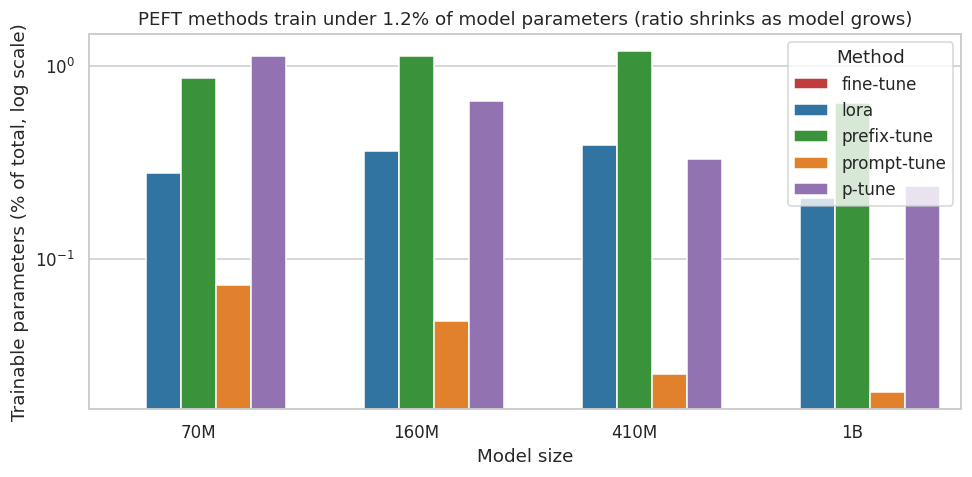

In [79]:
fig, ax = plt.subplots(figsize=(9, 4.5))
peft_only = df[(df["method"] != "fine-tune") & (df["hardware"] == "CUDA")]
sns.barplot(
    data=peft_only,
    x="model_short",
    y="trainable_pct",
    hue="method",
    palette=METHOD_PALETTE,
    ax=ax,
)
ax.set_yscale("log")
ax.set_ylabel("Trainable parameters (% of total, log scale)")
ax.set_xlabel("Model size")
ax.set_title(
    "PEFT methods train under 1.2% of model parameters (ratio shrinks as model grows)"
)
ax.legend(title="Method", loc="upper right")
plt.tight_layout()
plt.show()

## 4. Peak VRAM usage during training

We log peak GPU memory through a PyTorch allocator hook in the training callback and convert bytes to MB here. The ROCm 1B fine-tune cell is annotated because it required gradient checkpointing to fit under the 16 GB ceiling of the AMD RX 9060 XT card; the A100 used for CUDA experiments had enough headroom that no checkpointing was needed.

In [80]:
vram_table = df.pivot_table(
    index=["hardware", "model_short"],
    columns="method",
    values="vram_mb",
    observed=False,
).round(0)
vram_table

method                fine-tune     lora  prefix-tune  prompt-tune   p-tune
hardware model_short                                                       
CUDA     70M             4891.0   4368.0       4279.0       4928.0   4562.0
         160M            6882.0   5706.0       5433.0       6358.0   5908.0
         410M           11750.0   9062.0       8322.0       9906.0   9203.0
         1B             16280.0  11548.0      10538.0      12548.0  11736.0
ROCm     70M             5042.0   4519.0       4430.0       5079.0   4713.0
         160M            7033.0   5857.0       5584.0       6508.0   6059.0
         410M           11880.0   9212.0       8474.0      10057.0   9353.0
         1B              8755.0  11699.0      10688.0      12699.0  11887.0

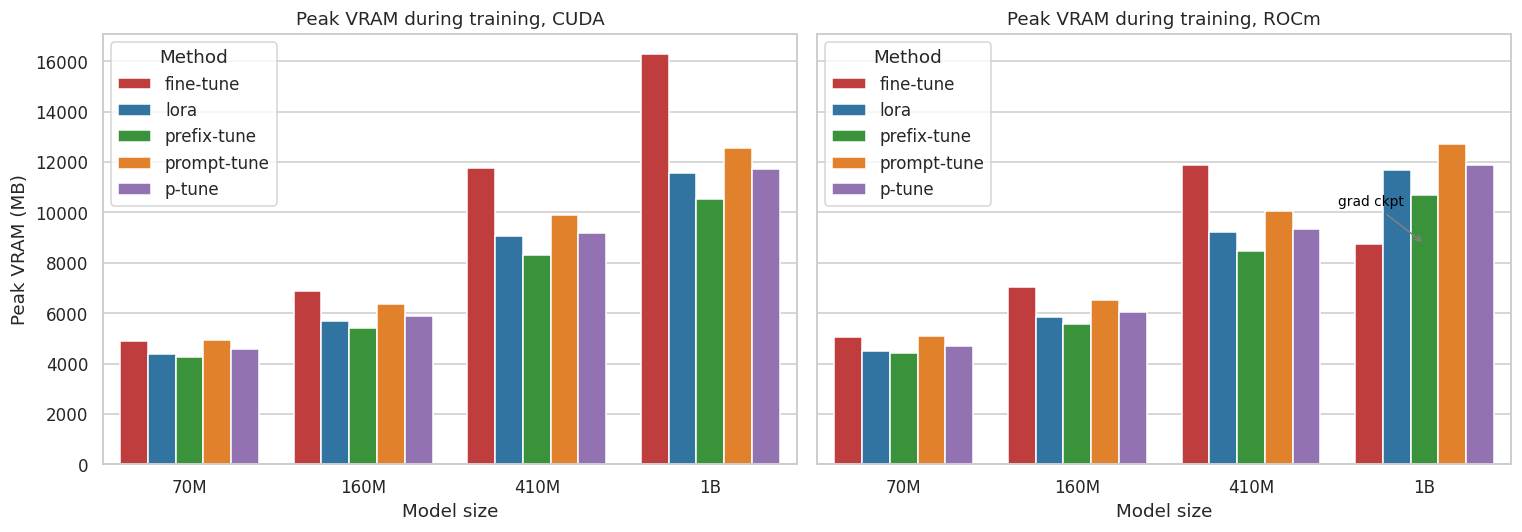

In [81]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
for ax, hw in zip(axes, ["CUDA", "ROCm"]):
    d = df[df["hardware"] == hw]
    sns.barplot(
        data=d,
        x="model_short",
        y="vram_mb",
        hue="method",
        palette=METHOD_PALETTE,
        ax=ax,
    )
    ax.set_title(f"Peak VRAM during training, {hw}")
    ax.set_xlabel("Model size")
    ax.set_ylabel("Peak VRAM (MB)")
    ax.legend(title="Method")
    if hw == "ROCm":
        gc = d[d["grad_ckpt"]]
        for _, row in gc.iterrows():
            ax.annotate(
                "grad ckpt",
                xy=(3, row["vram_mb"]),
                xytext=(2.5, row["vram_mb"] + 1500),
                fontsize=9,
                color="black",
                arrowprops={"arrowstyle": "->", "color": "gray"},
            )
plt.tight_layout()
plt.show()

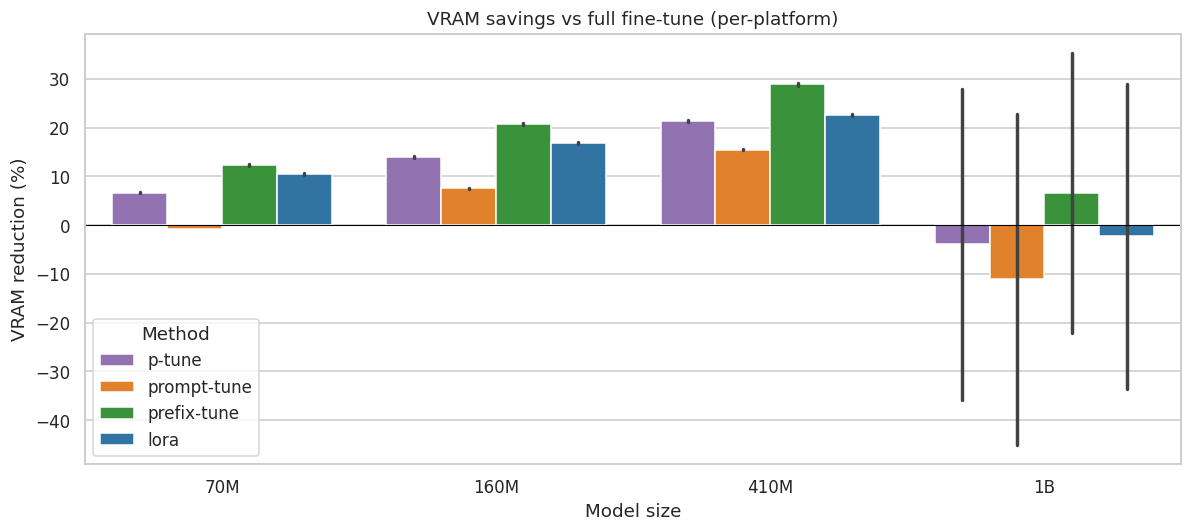

Note: ROCm 1B full fine-tune used gradient checkpointing, which makes PEFT "savings" appear negative for that cell.


In [82]:
def savings_vs_ft(d: pd.DataFrame) -> pd.DataFrame:
    out = []
    for (hw, ms), g in d.groupby(["hardware", "model_short"], observed=False):
        ft_row = g[g["method"] == "fine-tune"]
        if ft_row.empty:
            continue
        ft_vram = ft_row["vram_mb"].iloc[0]
        for _, row in g.iterrows():
            out.append(
                {
                    "hardware": hw,
                    "model_short": ms,
                    "method": row["method"],
                    "vram_saving_pct": (1 - row["vram_mb"] / ft_vram) * 100,
                    "grad_ckpt_ft": bool(ft_row["grad_ckpt"].iloc[0]),
                }
            )
    return pd.DataFrame(out)


sav = savings_vs_ft(df)
sav_peft = sav[sav["method"] != "fine-tune"]
fig, ax = plt.subplots(figsize=(11, 5))
sns.barplot(
    data=sav_peft,
    x="model_short",
    y="vram_saving_pct",
    hue="method",
    palette=METHOD_PALETTE,
    ax=ax,
    order=["70M", "160M", "410M", "1B"],
)
ax.axhline(0, color="black", linewidth=0.7)
ax.set_title("VRAM savings vs full fine-tune (per-platform)")
ax.set_ylabel("VRAM reduction (%)")
ax.set_xlabel("Model size")
ax.legend(title="Method")
plt.tight_layout()
plt.show()
print(
    "Note: ROCm 1B full fine-tune used gradient checkpointing,"
    ' which makes PEFT "savings" appear negative for that cell.'
)

## 5. Training runtime and throughput

Wall-clock time and samples per second over the full 1024-step training run. We expect PEFT to be faster because the optimizer only updates a small number of parameters.

In [83]:
runtime_table = df.pivot_table(
    index=["hardware", "model_short"],
    columns="method",
    values="train_runtime",
    observed=False,
).round(1)
runtime_table

method                fine-tune   lora  prefix-tune  prompt-tune  p-tune
hardware model_short                                                    
CUDA     70M               35.2   28.9         25.0         27.1    26.9
         160M              64.4   51.9         43.0         44.5    43.7
         410M             127.8  100.6         81.5         83.0    79.0
         1B               152.9   88.4         85.1        109.1    89.4
ROCm     70M               60.9   37.9         37.8         50.8    41.7
         160M             110.6   66.5         67.6         87.8    70.8
         410M             271.5  143.7        148.0        188.2   148.9
         1B               711.7  279.5        287.8        402.3   306.7

In [84]:
throughput_table = df.pivot_table(
    index=["hardware", "model_short"],
    columns="method",
    values="train_samples_per_second",
    observed=False,
).round(1)
throughput_table

method                fine-tune   lora  prefix-tune  prompt-tune  p-tune
hardware model_short                                                    
CUDA     70M              233.0  283.1        327.3        301.9   304.5
         160M             127.2  157.9        190.4        184.2   187.3
         410M              64.1   81.4        100.5         98.8   103.7
         1B                53.6   92.7         96.3         75.1    91.6
ROCm     70M              134.5  216.1        216.5        161.3   196.3
         160M              74.1  123.2        121.2         93.3   115.7
         410M              30.2   57.0         55.4         43.5    55.0
         1B                11.5   29.3         28.5         20.4    26.7

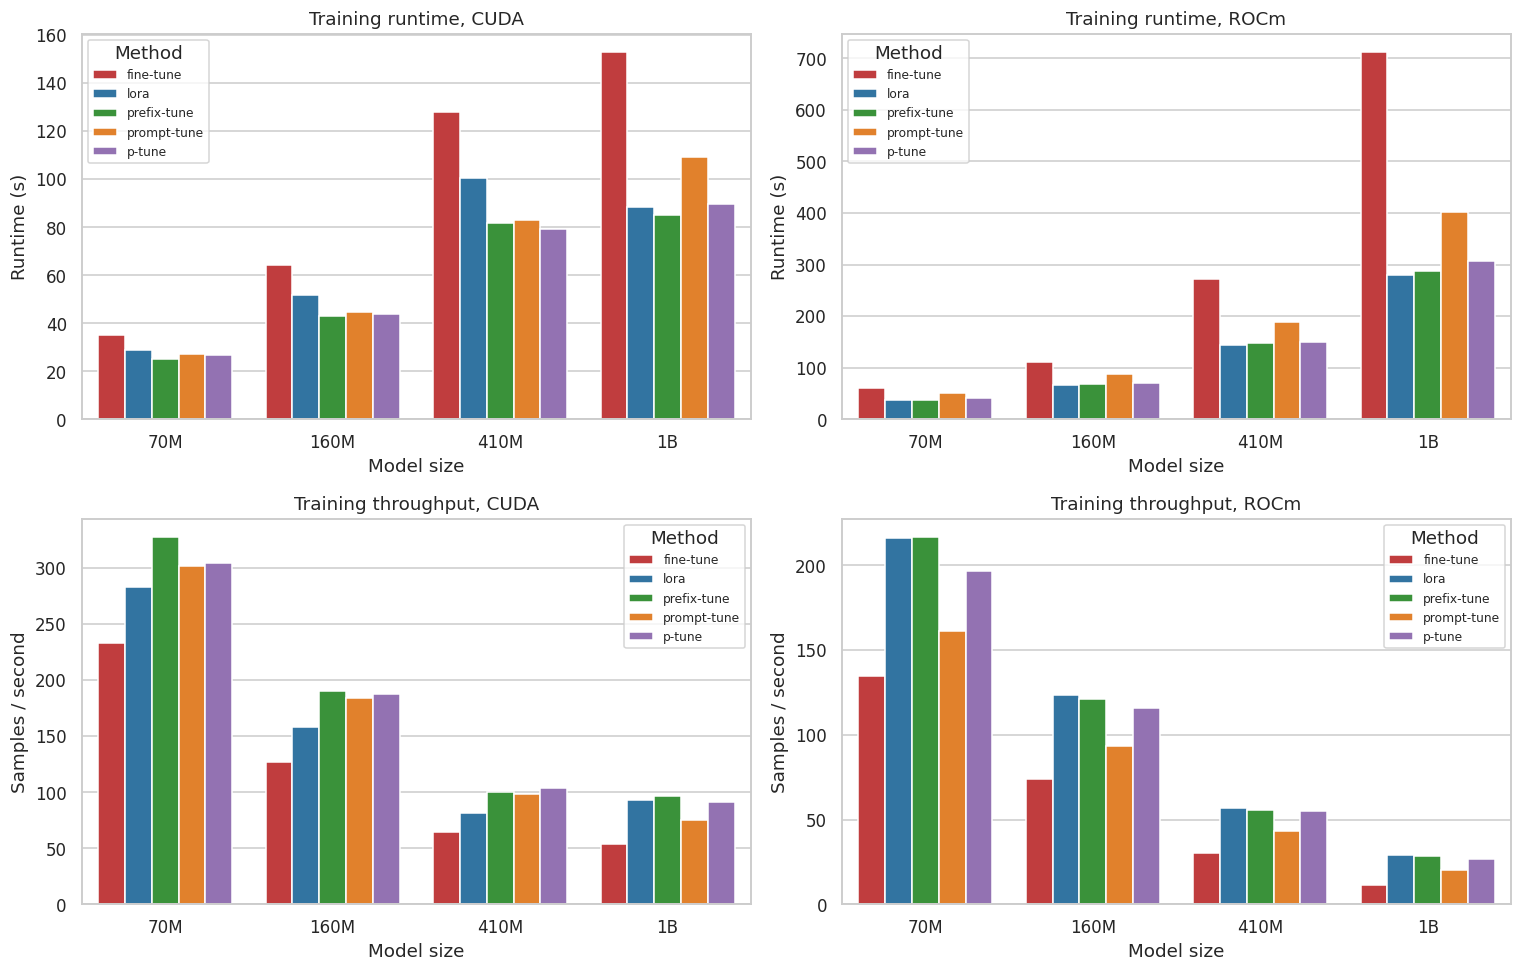

In [85]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
for col, hw in enumerate(["CUDA", "ROCm"]):
    d = df[df["hardware"] == hw]
    sns.barplot(
        data=d,
        x="model_short",
        y="train_runtime",
        hue="method",
        palette=METHOD_PALETTE,
        ax=axes[0, col],
    )
    axes[0, col].set_title(f"Training runtime, {hw}")
    axes[0, col].set_ylabel("Runtime (s)")
    axes[0, col].set_xlabel("Model size")
    axes[0, col].legend(title="Method", fontsize=8)
    sns.barplot(
        data=d,
        x="model_short",
        y="train_samples_per_second",
        hue="method",
        palette=METHOD_PALETTE,
        ax=axes[1, col],
    )
    axes[1, col].set_title(f"Training throughput, {hw}")
    axes[1, col].set_ylabel("Samples / second")
    axes[1, col].set_xlabel("Model size")
    axes[1, col].legend(title="Method", fontsize=8)
plt.tight_layout()
plt.show()

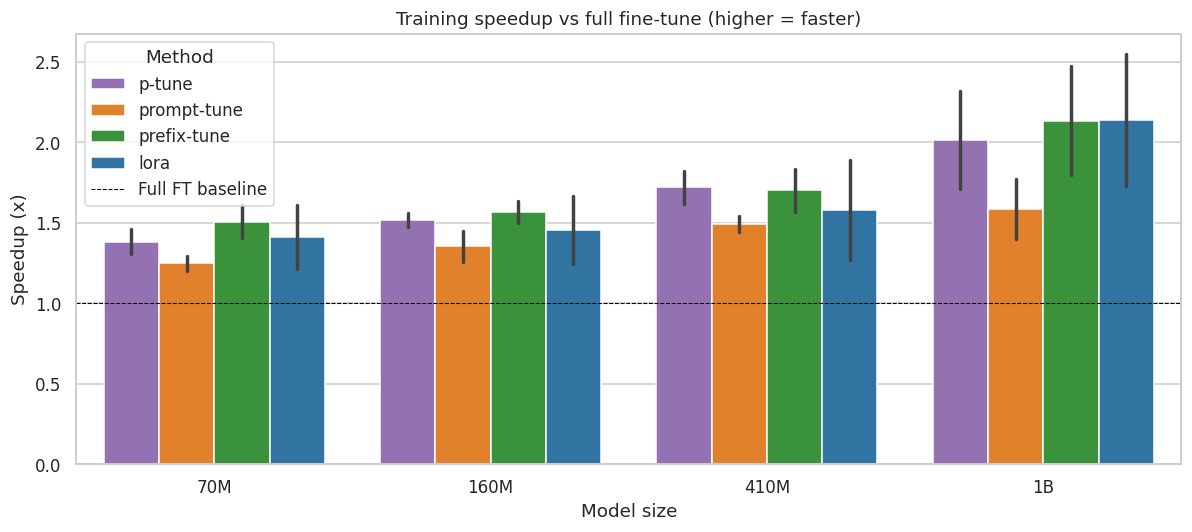

In [86]:
def speedup(d: pd.DataFrame) -> pd.DataFrame:
    out = []
    for (hw, ms), g in d.groupby(["hardware", "model_short"], observed=False):
        ft_row = g[g["method"] == "fine-tune"]
        if ft_row.empty:
            continue
        ft_t = ft_row["train_runtime"].iloc[0]
        for _, row in g.iterrows():
            out.append(
                {
                    "hardware": hw,
                    "model_short": ms,
                    "method": row["method"],
                    "speedup": ft_t / row["train_runtime"],
                }
            )
    return pd.DataFrame(out)


spd = speedup(df)
spd_peft = spd[spd["method"] != "fine-tune"]
fig, ax = plt.subplots(figsize=(11, 5))
sns.barplot(
    data=spd_peft,
    x="model_short",
    y="speedup",
    hue="method",
    palette=METHOD_PALETTE,
    ax=ax,
    order=["70M", "160M", "410M", "1B"],
)
ax.axhline(1.0, color="black", linewidth=0.7, linestyle="--", label="Full FT baseline")
ax.set_title("Training speedup vs full fine-tune (higher = faster)")
ax.set_ylabel("Speedup (x)")
ax.set_xlabel("Model size")
ax.legend(title="Method")
plt.tight_layout()
plt.show()

## 6. Loss

Final training loss and final inference (eval) loss for every run. All methods share a single learning rate of `5e-5`, which is a standard fine-tuning value but is generally too low for soft-prompt methods that need a higher LR on their prompt embeddings. We come back to this in the failure-case section.

In [87]:
loss_table = df.pivot_table(
    index=["hardware", "model_short"],
    columns="method",
    values="train_loss",
    observed=False,
).round(2)
loss_table

method                fine-tune  lora  prefix-tune  prompt-tune  p-tune
hardware model_short                                                   
CUDA     70M               5.86  6.11         8.18         6.89    6.65
         160M              4.71  4.33         7.81         4.89    5.35
         410M              3.05  3.14         8.44         3.77    3.21
         1B                2.78  2.84         5.42         3.54    2.88
ROCm     70M               6.04  6.12         8.00         6.80    6.47
         160M              4.70  4.35         7.17         4.91    4.63
         410M              3.13  3.14         8.70         3.80    3.23
         1B                2.78  2.85         5.18         3.62    2.87

In [88]:
inf_loss_table = df.pivot_table(
    index=["hardware", "model_short"],
    columns="method",
    values="inference_loss",
    observed=False,
).round(2)
inf_loss_table

method                fine-tune  lora  prefix-tune  prompt-tune  p-tune
hardware model_short                                                   
CUDA     70M               5.76  6.07         8.21         7.02    6.68
         160M              4.52  4.35         7.83         5.02    5.48
         410M              2.90  3.10         8.26         3.86    3.19
         1B                2.61  2.80         5.15         3.61    2.88
ROCm     70M               5.96  6.12         8.01         6.94    6.59
         160M              4.50  4.37         7.23         5.05    4.62
         410M              2.99  3.10         8.52         3.91    3.20
         1B                2.61  2.80         4.99         3.69    2.87

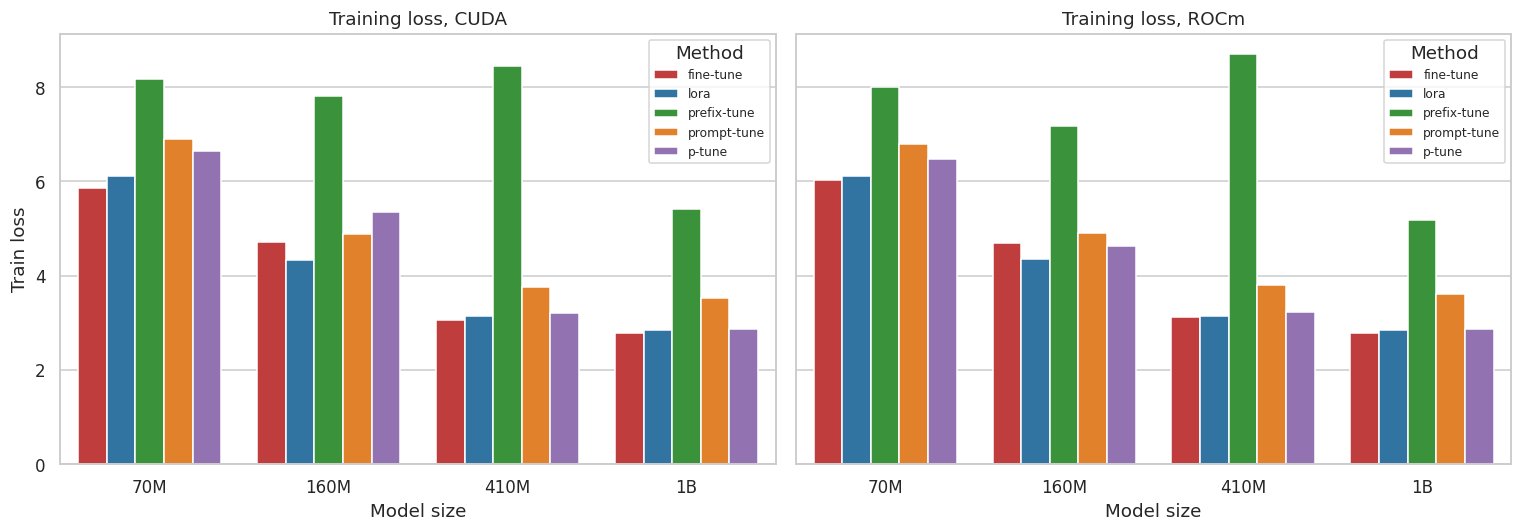

In [89]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
for ax, hw in zip(axes, ["CUDA", "ROCm"]):
    d = df[df["hardware"] == hw]
    sns.barplot(
        data=d,
        x="model_short",
        y="train_loss",
        hue="method",
        palette=METHOD_PALETTE,
        ax=ax,
    )
    ax.set_title(f"Training loss, {hw}")
    ax.set_xlabel("Model size")
    ax.set_ylabel("Train loss")
    ax.legend(title="Method", fontsize=8)
plt.tight_layout()
plt.show()

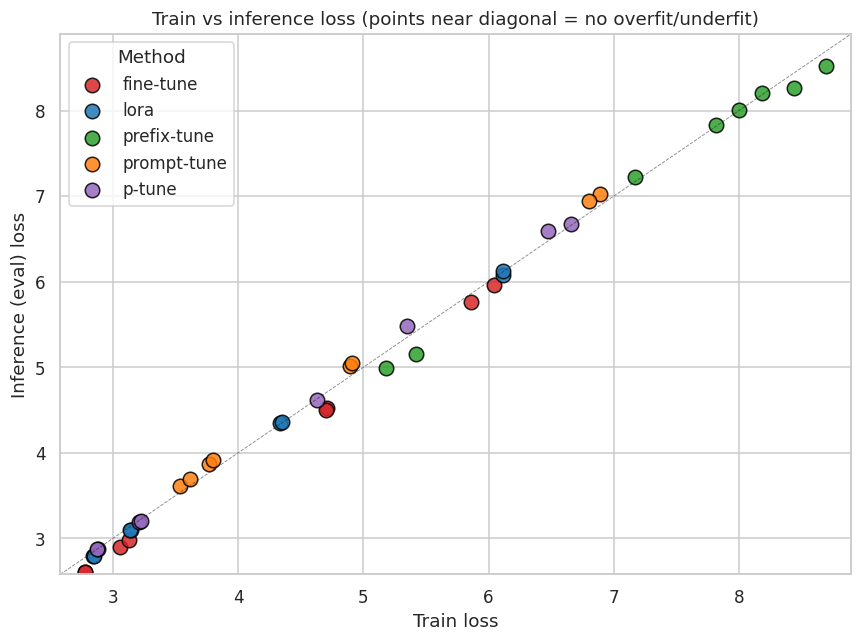

In [90]:
fig, ax = plt.subplots(figsize=(8, 6))
for method, color in METHOD_PALETTE.items():
    d = df[df["method"] == method]
    ax.scatter(
        d["train_loss"],
        d["inference_loss"],
        color=color,
        label=method,
        s=90,
        alpha=0.85,
        edgecolor="black",
    )
lims = [df["train_loss"].min() - 0.2, df["train_loss"].max() + 0.2]
ax.plot(lims, lims, "k--", linewidth=0.6, alpha=0.5)
ax.set_xlim(lims)
ax.set_ylim(lims)
ax.set_xlabel("Train loss")
ax.set_ylabel("Inference (eval) loss")
ax.set_title("Train vs inference loss (points near diagonal = no overfit/underfit)")
ax.legend(title="Method")
plt.tight_layout()
plt.show()

## 7. Floating-point operations (FLOPs)

FLOPs counted by the HuggingFace `Trainer`. The point of this section is to check whether the PEFT methods actually reduce compute, or only reduce optimizer state and gradient memory.

In [91]:
flops_table = df.pivot_table(
    index=["hardware", "model_short"],
    columns="method",
    values="flops_t",
    observed=False,
).round(1)
flops_table

method                fine-tune     lora  prefix-tune  prompt-tune   p-tune
hardware model_short                                                       
CUDA     70M              494.5    496.6        494.5        494.5    494.5
         160M            1369.1   1375.6       1369.1       1369.1   1369.1
         410M            3916.4   3933.8       3916.4       3916.4   3916.4
         1B             10058.9  10082.1      10058.9      10058.9  10058.9
ROCm     70M              494.5    496.6        494.5        494.5    494.5
         160M            1369.1   1375.6       1369.1       1369.1   1369.1
         410M            3916.4   3933.8       3916.4       3916.4   3916.4
         1B             10058.9  10082.1      10058.9      10058.9  10058.9

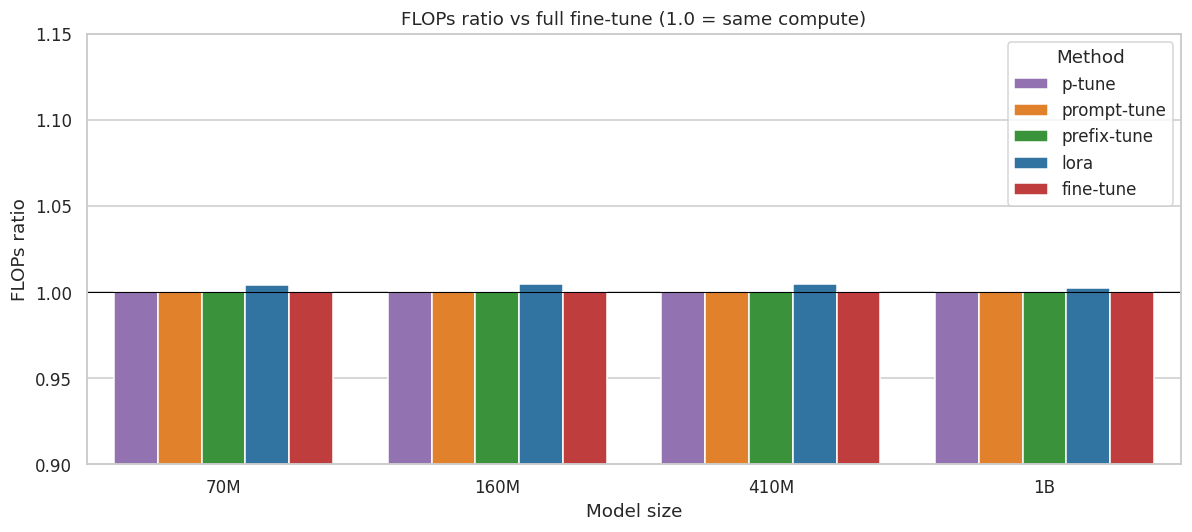

In [92]:
def flops_ratio(d: pd.DataFrame) -> pd.DataFrame:
    out = []
    for (hw, ms), g in d.groupby(["hardware", "model_short"], observed=False):
        ft_row = g[g["method"] == "fine-tune"]
        if ft_row.empty:
            continue
        ft = ft_row["flops_t"].iloc[0]
        for _, row in g.iterrows():
            out.append(
                {
                    "hardware": hw,
                    "model_short": ms,
                    "method": row["method"],
                    "flops_ratio": row["flops_t"] / ft,
                }
            )
    return pd.DataFrame(out)


fl = flops_ratio(df)
fig, ax = plt.subplots(figsize=(11, 5))
sns.barplot(
    data=fl,
    x="model_short",
    y="flops_ratio",
    hue="method",
    palette=METHOD_PALETTE,
    ax=ax,
    order=["70M", "160M", "410M", "1B"],
)
ax.axhline(1.0, color="black", linewidth=0.7)
ax.set_ylim(0.9, 1.15)
ax.set_title("FLOPs ratio vs full fine-tune (1.0 = same compute)")
ax.set_ylabel("FLOPs ratio")
ax.set_xlabel("Model size")
ax.legend(title="Method")
plt.tight_layout()
plt.show()

## 8. Inference performance

We separate training and inference timing because PEFT adapters and virtual tokens still get evaluated at inference, so the speedups seen during training do not necessarily carry over.

In [93]:
inf_throughput = df.pivot_table(
    index=["hardware", "model_short"],
    columns="method",
    values="inference_samples_per_second",
    observed=False,
).round(1)
inf_throughput

method                fine-tune   lora  prefix-tune  prompt-tune  p-tune
hardware model_short                                                    
CUDA     70M              615.4  552.7        571.5        536.7   558.6
         160M             389.7  336.3        362.4        351.7   361.9
         410M             225.9  187.2        207.3        209.4   217.2
         1B               255.5  229.8        234.6        188.3   226.5
ROCm     70M              516.9  498.2        484.5        357.7   449.1
         160M             321.7  301.1        292.3        219.9   280.5
         410M             156.1  142.4        137.0        106.5   136.1
         1B                73.7   68.7         68.3         48.4    63.3

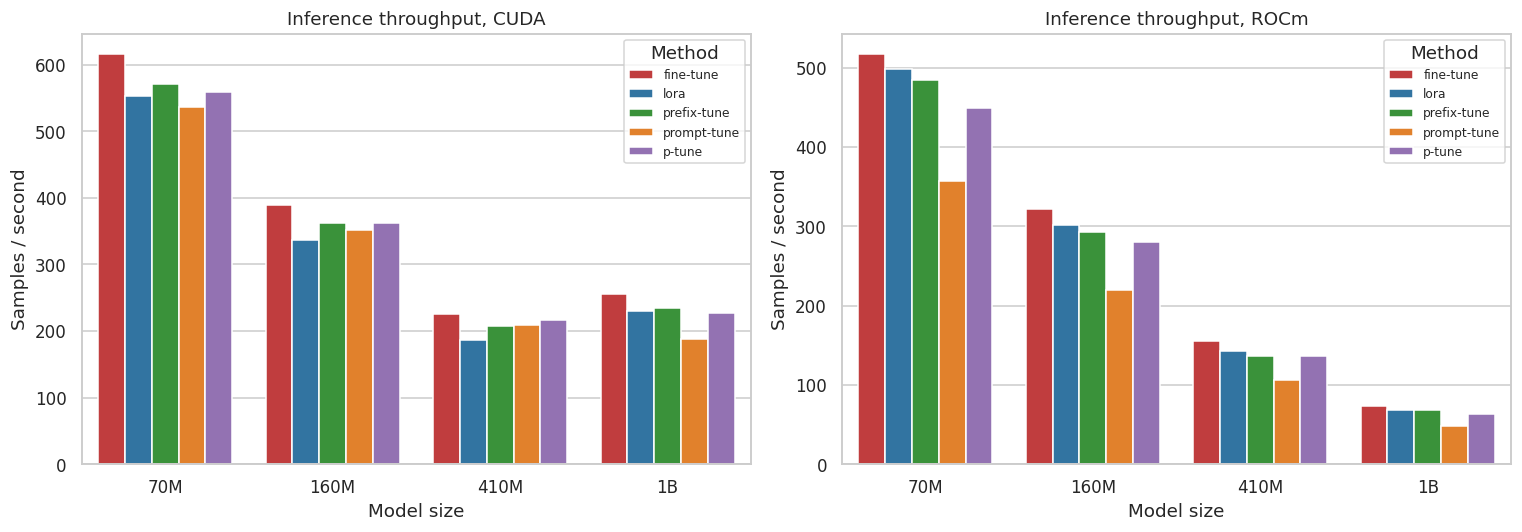

In [94]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, hw in zip(axes, ["CUDA", "ROCm"]):
    d = df[df["hardware"] == hw]
    sns.barplot(
        data=d,
        x="model_short",
        y="inference_samples_per_second",
        hue="method",
        palette=METHOD_PALETTE,
        ax=ax,
    )
    ax.set_title(f"Inference throughput, {hw}")
    ax.set_ylabel("Samples / second")
    ax.set_xlabel("Model size")
    ax.legend(title="Method", fontsize=8)
plt.tight_layout()
plt.show()

## 9. CUDA vs ROCm comparison

Same model and method, run on the two different cards. We use this to answer research question 3: how much do the metrics actually differ between accelerators?

In [95]:
merge_cols = ["model_short", "method"]
metrics_keep = [
    "vram_mb",
    "train_runtime",
    "train_samples_per_second",
    "train_loss",
    "inference_samples_per_second",
    "grad_ckpt",
]
left = cuda.assign(model_short=cuda["model"].map(MODEL_SHORT))[
    merge_cols + metrics_keep + ["gradient_checkpointing"]
].rename(columns={c: c + "_cuda" for c in metrics_keep})
left["grad_ckpt_cuda"] = left["gradient_checkpointing"].astype(str) == "True"
left = left.drop(columns=["gradient_checkpointing"])
right = rocm.assign(model_short=rocm["model"].map(MODEL_SHORT))[
    merge_cols + metrics_keep + ["gradient_checkpointing"]
].rename(columns={c: c + "_rocm" for c in metrics_keep})
right["grad_ckpt_rocm"] = right["gradient_checkpointing"].astype(str) == "True"
right = right.drop(columns=["gradient_checkpointing"])
comp = left.merge(right, on=merge_cols)
comp["vram_ratio_rocm_over_cuda"] = comp["vram_mb_rocm"] / comp["vram_mb_cuda"]
comp["runtime_ratio_rocm_over_cuda"] = (
    comp["train_runtime_rocm"] / comp["train_runtime_cuda"]
)
comp[
    [
        "model_short",
        "method",
        "vram_mb_cuda",
        "vram_mb_rocm",
        "vram_ratio_rocm_over_cuda",
        "runtime_ratio_rocm_over_cuda",
        "grad_ckpt_rocm",
    ]
].round(2)

,model_short,method,vram_mb_cuda,vram_mb_rocm,vram_ratio_rocm_over_cuda,runtime_ratio_rocm_over_cuda,grad_ckpt_rocm
0,1B,p-tune,11736.08,11886.80,1.01,3.43,False
1,1B,prompt-tune,12548.48,12699.22,1.01,3.69,False
2,1B,prefix-tune,10538.29,10688.01,1.01,3.38,False
3,1B,lora,11548.27,11698.99,1.01,3.16,False
4,1B,fine-tune,16280.31,8754.77,0.54,4.66,True
5,410M,p-tune,9203.23,9352.61,1.02,1.88,False
6,410M,prompt-tune,9905.87,10056.57,1.02,2.27,False
7,410M,prefix-tune,8322.18,8474.34,1.02,1.81,False
8,410M,lora,9061.74,9212.40,1.02,1.43,False
9,410M,fine-tune,11750.41,11880.39,1.01,2.12,False


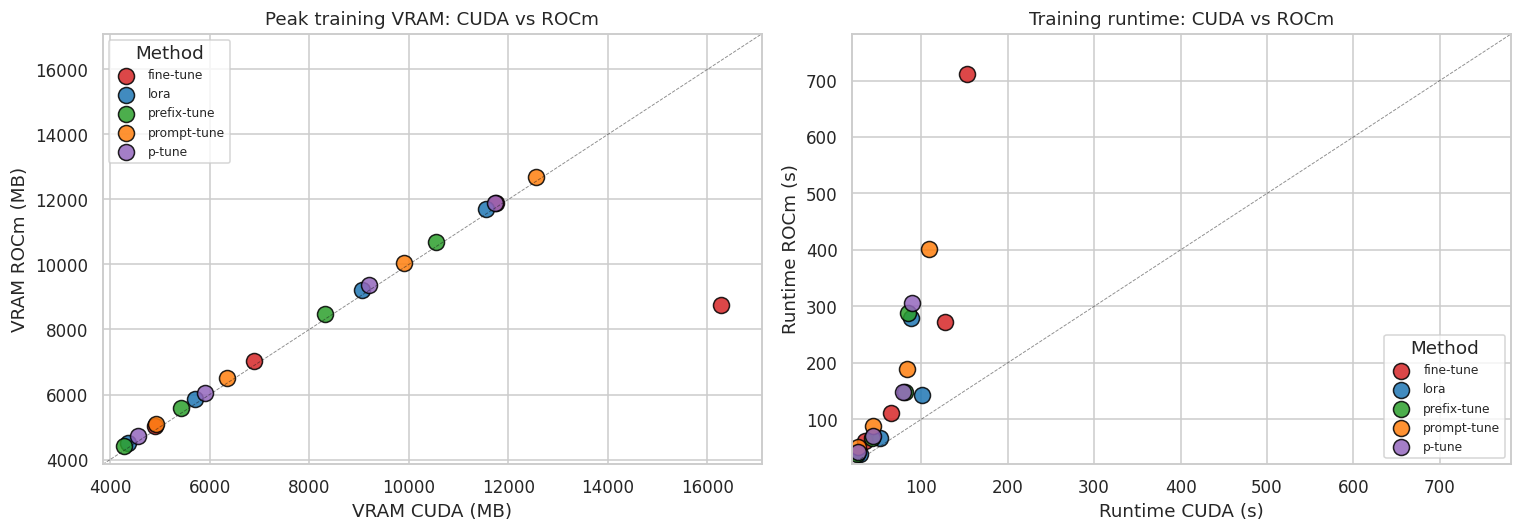

In [96]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for method, color in METHOD_PALETTE.items():
    d = comp[comp["method"] == method]
    axes[0].scatter(
        d["vram_mb_cuda"],
        d["vram_mb_rocm"],
        color=color,
        label=method,
        s=110,
        alpha=0.85,
        edgecolor="black",
    )
lims = [
    comp[["vram_mb_cuda", "vram_mb_rocm"]].min().min() * 0.9,
    comp[["vram_mb_cuda", "vram_mb_rocm"]].max().max() * 1.05,
]
axes[0].plot(lims, lims, "k--", linewidth=0.6, alpha=0.5)
axes[0].set_xlim(lims)
axes[0].set_ylim(lims)
axes[0].set_xlabel("VRAM CUDA (MB)")
axes[0].set_ylabel("VRAM ROCm (MB)")
axes[0].set_title("Peak training VRAM: CUDA vs ROCm")
axes[0].legend(title="Method", fontsize=8)
for method, color in METHOD_PALETTE.items():
    d = comp[comp["method"] == method]
    axes[1].scatter(
        d["train_runtime_cuda"],
        d["train_runtime_rocm"],
        color=color,
        label=method,
        s=110,
        alpha=0.85,
        edgecolor="black",
    )
lims = [
    comp[["train_runtime_cuda", "train_runtime_rocm"]].min().min() * 0.8,
    comp[["train_runtime_cuda", "train_runtime_rocm"]].max().max() * 1.1,
]
axes[1].plot(lims, lims, "k--", linewidth=0.6, alpha=0.5)
axes[1].set_xlim(lims)
axes[1].set_ylim(lims)
axes[1].set_xlabel("Runtime CUDA (s)")
axes[1].set_ylabel("Runtime ROCm (s)")
axes[1].set_title("Training runtime: CUDA vs ROCm")
axes[1].legend(title="Method", fontsize=8)
plt.tight_layout()
plt.show()

## 10. Trade-off view

A single picture of the VRAM, throughput, and loss axes together. Bubble size is inversely proportional to training loss so larger bubbles mean better convergence.

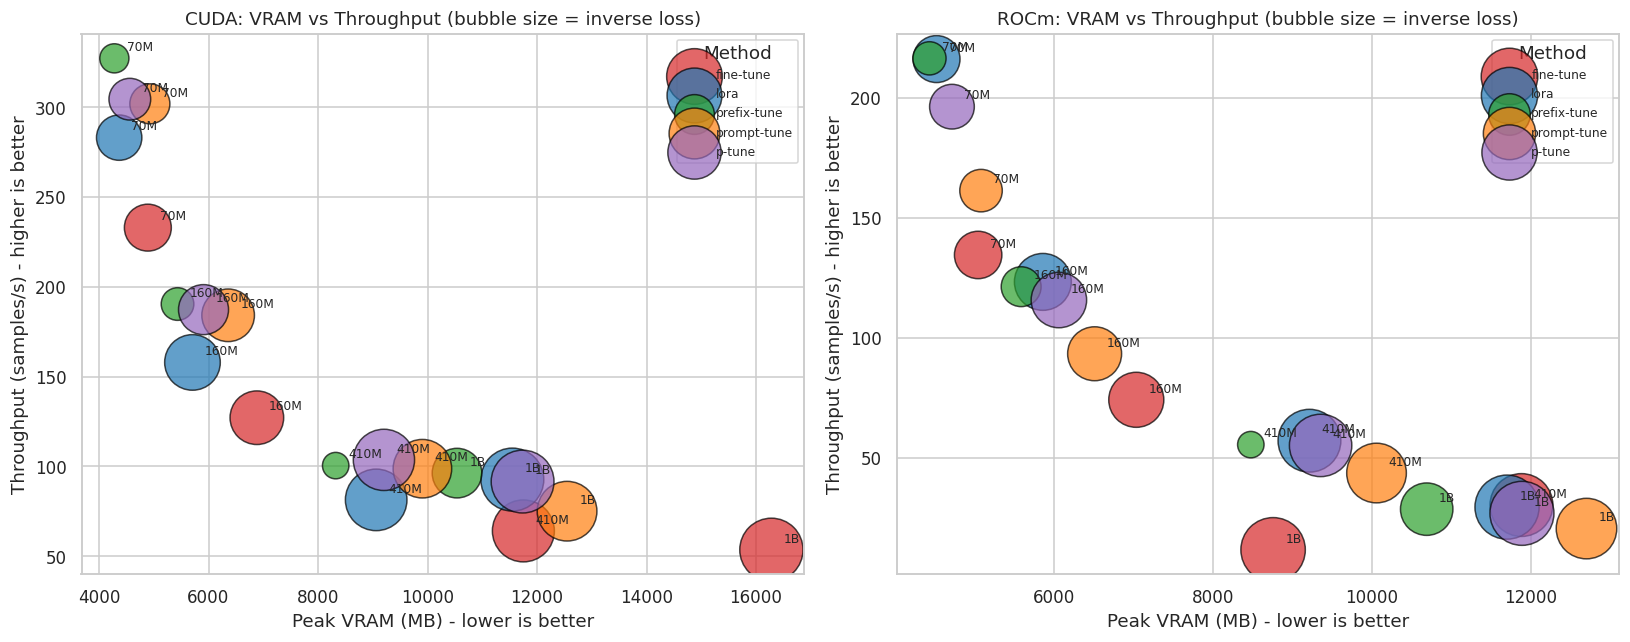

In [97]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
for ax, hw in zip(axes, ["CUDA", "ROCm"]):
    d = df[df["hardware"] == hw].copy()
    max_loss = d["train_loss"].max()
    d["bubble"] = 300 + (max_loss - d["train_loss"]) * 250
    for method, color in METHOD_PALETTE.items():
        dm = d[d["method"] == method]
        ax.scatter(
            dm["vram_mb"],
            dm["train_samples_per_second"],
            s=dm["bubble"],
            color=color,
            label=method,
            alpha=0.7,
            edgecolor="black",
        )
        for _, row in dm.iterrows():
            ax.annotate(
                row["model_short"],
                (row["vram_mb"], row["train_samples_per_second"]),
                textcoords="offset points",
                xytext=(8, 5),
                fontsize=8,
            )
    ax.set_xlabel("Peak VRAM (MB) - lower is better")
    ax.set_ylabel("Throughput (samples/s) - higher is better")
    ax.set_title(f"{hw}: VRAM vs Throughput (bubble size = inverse loss)")
    ax.legend(title="Method", fontsize=8, loc="upper right")
plt.tight_layout()
plt.show()

## 11. Step-level training loss curves

The CSV export only stores final loss, so we read step-level loss directly from the MLflow SQLite stores. With 10 logged points per run we can see whether each method actually converged or just stalled.

In [98]:
def load_loss_curves(db_path: str, hardware: str) -> pd.DataFrame:
    con = sqlite3.connect(db_path)
    q = (
        "SELECT r.name, m.step, m.value FROM metrics m "
        "JOIN runs r ON m.run_uuid = r.run_uuid "
        "WHERE m.key = 'loss' AND r.lifecycle_stage = 'active' "
        "ORDER BY r.name, m.step"
    )
    rows = con.execute(q).fetchall()
    con.close()
    out = []
    for name, step, value in rows:
        parts = name.split("/")
        model = "/".join(parts[:-2])
        method = parts[-1]
        out.append(
            {
                "hardware": hardware,
                "model": model,
                "method": method,
                "step": step,
                "loss": value,
                "model_short": MODEL_SHORT.get(model, model),
            }
        )
    return pd.DataFrame(out)


try:
    curves_cuda = load_loss_curves("mlflow-cuda.db", "CUDA")
    curves_rocm = load_loss_curves("mlflow-rocm.db", "ROCm")
    curves = pd.concat([curves_cuda, curves_rocm], ignore_index=True)
    print(f"Loaded {len(curves)} loss points")
    curves.head()
except Exception as e:
    print(f"Could not load MLflow DBs: {e}")
    print("Upload mlflow-cuda.db and mlflow-rocm.db to Colab to enable this section.")
    curves = None
curves.head() if curves is not None else None

Loaded 400 loss points


,hardware,model,method,step,loss,model_short
0,CUDA,EleutherAI/pythia-160m,fine-tune,102,4.816477,160M
1,CUDA,EleutherAI/pythia-160m,fine-tune,204,4.979423,160M
2,CUDA,EleutherAI/pythia-160m,fine-tune,306,4.949460,160M
3,CUDA,EleutherAI/pythia-160m,fine-tune,408,4.898456,160M
4,CUDA,EleutherAI/pythia-160m,fine-tune,510,4.746852,160M


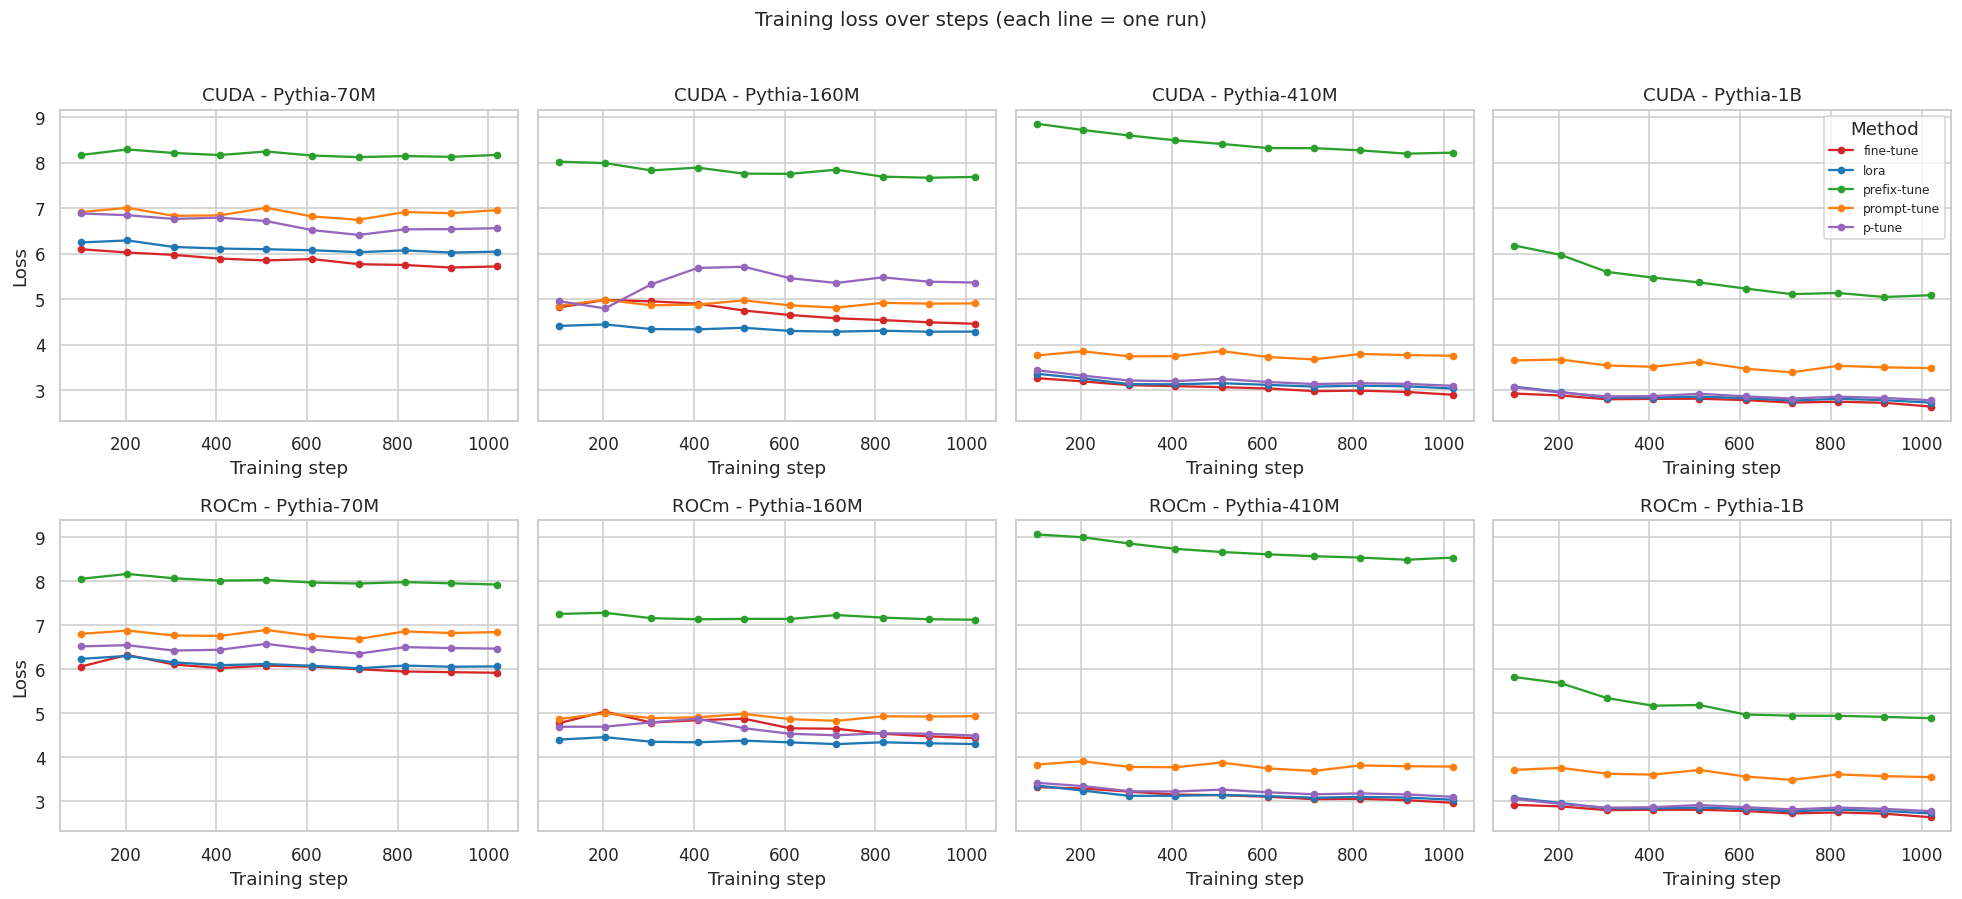

In [109]:
if curves is not None:
    fig, axes = plt.subplots(2, 4, figsize=(18, 8), sharey="row")
    for row, hw in enumerate(["CUDA", "ROCm"]):
        for col, ms in enumerate(["70M", "160M", "410M", "1B"]):
            ax = axes[row, col]
            d = curves[(curves["hardware"] == hw) & (curves["model_short"] == ms)]
            for method, color in METHOD_PALETTE.items():
                dm = d[d["method"] == method].sort_values("step")
                if not dm.empty:
                    ax.plot(
                        dm["step"],
                        dm["loss"],
                        "-o",
                        color=color,
                        label=method,
                        markersize=4,
                        linewidth=1.5,
                    )
            ax.set_title(f"{hw} - Pythia-{ms}")
            ax.set_xlabel("Training step")
            ax.set_ylabel("Loss" if col == 0 else "")
            if row == 0 and col == 3:
                ax.legend(title="Method", fontsize=8, loc="upper right")
    plt.suptitle("Training loss over steps (each line = one run)", y=1.02, fontsize=13)
    plt.tight_layout()
    plt.show()
else:
    print("Skipped: MLflow DBs not loaded.")

In [100]:
# Convergence rate: relative loss reduction from step 0 to final step
conv_pivot = None
if curves is not None:
    conv = []
    for (hw, ms, method), g in curves.groupby(
        ["hardware", "model_short", "method"], observed=False
    ):
        g = g.sort_values("step")
        if len(g) < 2:
            continue
        start, end = g["loss"].iloc[0], g["loss"].iloc[-1]
        conv.append(
            {
                "hardware": hw,
                "model_short": ms,
                "method": method,
                "start_loss": start,
                "end_loss": end,
                "rel_reduction_pct": (start - end) / start * 100,
            }
        )
    conv_df = pd.DataFrame(conv)
    conv_pivot = conv_df.pivot_table(
        index=["hardware", "model_short"],
        columns="method",
        values="rel_reduction_pct",
        observed=False,
    ).round(1)
    print("Relative loss reduction (start to end), % - higher = converged more:")
conv_pivot

Relative loss reduction (start to end), % - higher = converged more:


method                fine-tune  lora  p-tune  prefix-tune  prompt-tune
hardware model_short                                                   
CUDA     160M               7.5   2.8    -8.3          4.2         -1.1
         1B                 9.8  11.4     9.3         17.7          4.6
         410M              11.2   9.7    10.0          7.2          0.2
         70M                6.2   3.2     4.7         -0.0         -0.6
ROCm     160M               7.1   2.3     4.3          1.8         -1.3
         1B                 9.7  11.4     9.1         16.1          4.4
         410M              10.7   9.6     9.3          5.8          1.2
         70M                2.3   2.7     0.8          1.6         -0.6

## 12. Where does the memory go?

PyTorch's allocator reports two related numbers: *allocated* bytes (memory currently held by live tensors) and *reserved* bytes (memory the allocator has claimed from the OS, including cache for future allocations). We compare them to check that the VRAM savings we measured are real working-set differences, not allocator artefacts.

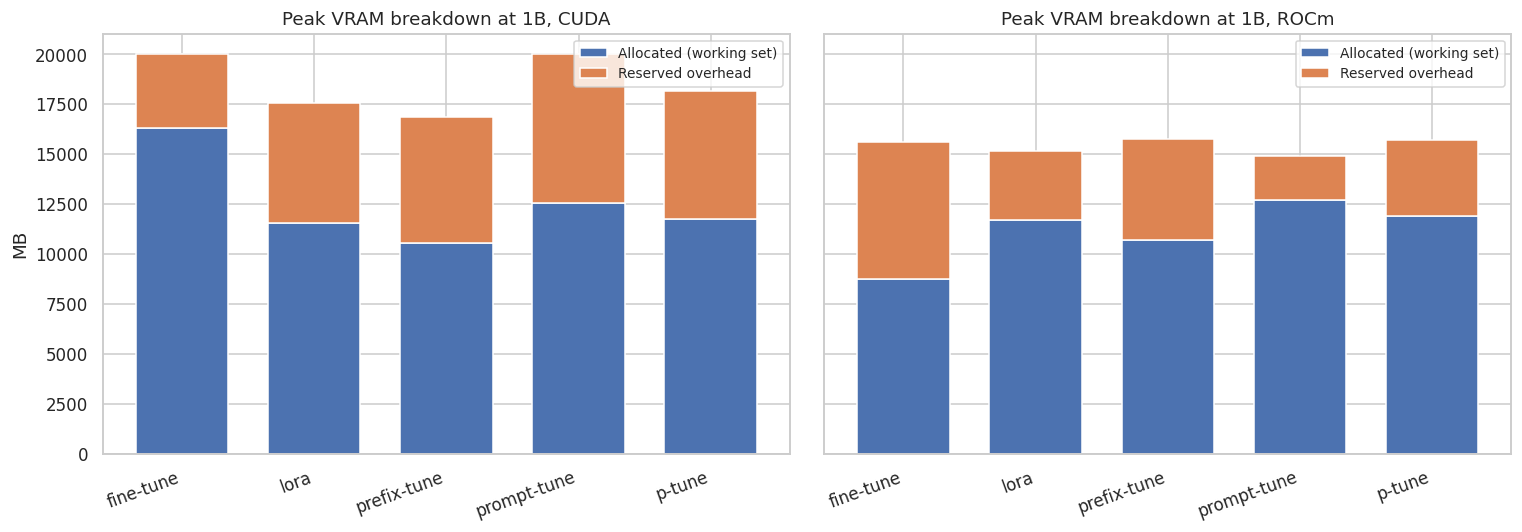

In [101]:
mem_long = []
for _, r in df.iterrows():
    overhead = r["vram_reserved_mb"] - r["vram_mb"]
    mem_long.append(
        {
            "hardware": r["hardware"],
            "model_short": r["model_short"],
            "method": r["method"],
            "type": "Allocated (working set)",
            "mb": r["vram_mb"],
        }
    )
    mem_long.append(
        {
            "hardware": r["hardware"],
            "model_short": r["model_short"],
            "method": r["method"],
            "type": "Reserved overhead",
            "mb": max(overhead, 0),
        }
    )
mem_df = pd.DataFrame(mem_long)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
for ax, hw in zip(axes, ["CUDA", "ROCm"]):
    d = mem_df[(mem_df["hardware"] == hw) & (mem_df["model_short"] == "1B")]
    pvt = d.pivot_table(
        index="method", columns="type", values="mb", observed=False
    ).reindex(METHOD_ORDER)
    pvt.plot.bar(stacked=True, ax=ax, color=["#4c72b0", "#dd8452"], width=0.7)
    ax.set_title(f"Peak VRAM breakdown at 1B, {hw}")
    ax.set_ylabel("MB")
    ax.set_xlabel("")
    ax.legend(loc="upper right", fontsize=9)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=20, ha="right")
plt.tight_layout()
plt.show()

In [102]:
# Reserved overhead as a fraction of allocated (across all runs)
df["overhead_pct"] = (df["vram_reserved_mb"] - df["vram_mb"]) / df["vram_mb"] * 100
df.pivot_table(
    index=["hardware", "model_short"],
    columns="method",
    values="overhead_pct",
    observed=False,
).round(1)

/tmp/ipykernel_30718/2822955659.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['overhead_pct'] = (df['vram_reserved_mb'] - df['vram_mb']) / df['vram_mb'] * 100


method                fine-tune   lora  prefix-tune  prompt-tune  p-tune
hardware model_short                                                    
CUDA     70M              152.0  177.5        182.6        186.9   181.0
         160M              96.9  129.6        137.9        138.3   133.9
         410M              46.5   70.6         81.0         80.5    76.3
         1B                22.7   51.8         60.1         59.5    54.9
ROCm     70M              145.7  170.1        174.4        179.9   173.6
         160M             101.4  125.3        132.7        133.9   129.3
         410M              25.1   68.8         78.7         51.1    60.8
         1B                78.1   29.5         47.2         17.3    32.2

## 13. Failure cases

Two things went wrong in our runs and we make them explicit here:

1. Prefix tuning never converged well. It has the highest final loss in every cell of our grid and the curves in section 11 show it barely moves from its starting loss on the smaller models.
2. Pythia-1B full fine-tune on ROCm could not fit in 16 GB. We re-ran it with gradient checkpointing enabled.

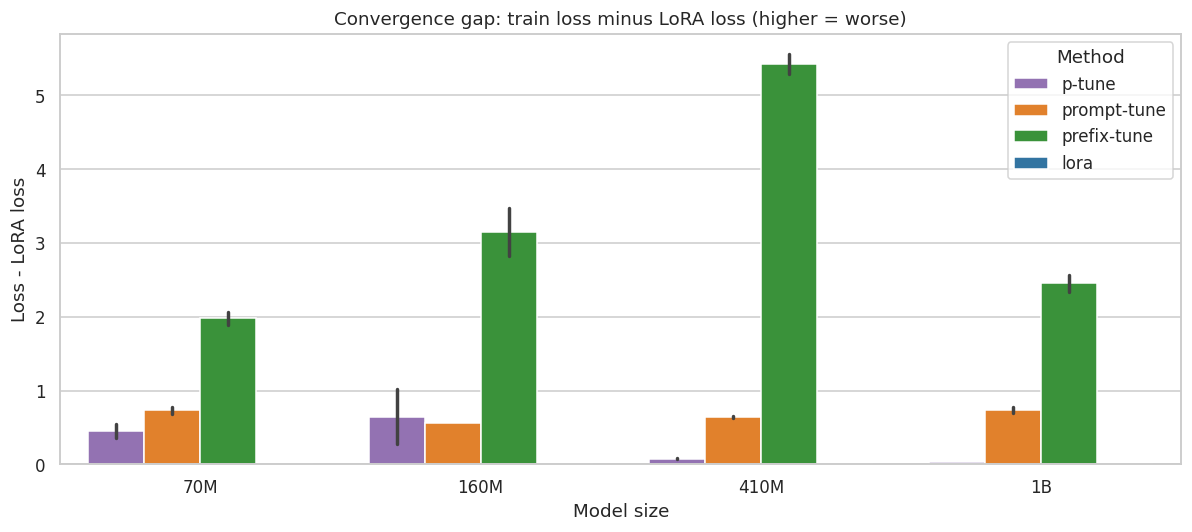

In [103]:
# Loss gap vs LoRA (the strongest PEFT baseline)
gaps = []
for (hw, ms), g in df.groupby(["hardware", "model_short"], observed=False):
    lora_row = g[g["method"] == "lora"]
    if lora_row.empty:
        continue
    lora_loss = lora_row["train_loss"].iloc[0]
    for _, row in g.iterrows():
        if row["method"] == "fine-tune":
            continue
        gaps.append(
            {
                "hardware": hw,
                "model_short": ms,
                "method": row["method"],
                "loss_gap_vs_lora": row["train_loss"] - lora_loss,
            }
        )
gaps_df = pd.DataFrame(gaps)

fig, ax = plt.subplots(figsize=(11, 5))
sns.barplot(
    data=gaps_df,
    x="model_short",
    y="loss_gap_vs_lora",
    hue="method",
    palette=METHOD_PALETTE,
    ax=ax,
    order=["70M", "160M", "410M", "1B"],
)
ax.axhline(0, color="black", linewidth=0.7)
ax.set_title("Convergence gap: train loss minus LoRA loss (higher = worse)")
ax.set_ylabel("Loss - LoRA loss")
ax.set_xlabel("Model size")
ax.legend(title="Method")
plt.tight_layout()
plt.show()

In [ ]:
# 1B memory ceiling visualization
fig, ax = plt.subplots(figsize=(9, 7))
d_1b = df[df["model_short"] == "1B"].copy().sort_values(["hardware", "method"])
d_1b["label"] = d_1b["hardware"].astype(str) + " / " + d_1b["method"].astype(str)
d_1b["note"] = d_1b.apply(lambda r: "  + grad ckpt" if r["grad_ckpt"] else "", axis=1)
colors = ["#1f77b4" if h == "CUDA" else "#d62728" for h in d_1b["hardware"]]
y = range(len(d_1b))
ax.barh(y, d_1b["vram_mb"], color=colors)
ax.set_yticks(y)
ax.set_yticklabels(d_1b["label"], fontsize=11)
ax.set_xlim(0, 19500)
for i, (mb, note) in enumerate(zip(d_1b["vram_mb"], d_1b["note"])):
    ax.text(mb + 200, i, f"{mb:.0f} MB{note}", va="center", fontsize=10)
ax.axvline(
    16384, color="black", linestyle="--", linewidth=1.5, label="16 GB ROCm card limit"
)
ax.set_xlabel("Peak VRAM allocated (MB)", fontsize=12)
ax.set_title("Pythia-1B peak training VRAM by platform and method", fontsize=13, pad=12)
ax.legend(loc="upper right", fontsize=10, framealpha=0.95)
ax.grid(axis="x", alpha=0.3, linewidth=0.5)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()
print(
    "Without gradient checkpointing, the ROCm 1B full fine-tune"
    " would have exceeded 16 GB and OOM'd."
)
print("CUDA had a larger card, so it ran without checkpointing at 16,280 MB.")

## 14. Inference latency

Throughput hides per-request wait time, so we also report single-sample latency in milliseconds as `1000 / inference_samples_per_second`. This matters more for interactive serving than for batch evaluation.

In [105]:
df["inf_latency_ms"] = 1000.0 / df["inference_samples_per_second"]
lat_table = df.pivot_table(
    index=["hardware", "model_short"],
    columns="method",
    values="inf_latency_ms",
    observed=False,
).round(2)
lat_table

/tmp/ipykernel_30718/3176475506.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['inf_latency_ms'] = 1000.0 / df['inference_samples_per_second']


method                fine-tune   lora  prefix-tune  prompt-tune  p-tune
hardware model_short                                                    
CUDA     70M               1.63   1.81         1.75         1.86    1.79
         160M              2.57   2.97         2.76         2.84    2.76
         410M              4.43   5.34         4.82         4.77    4.60
         1B                3.91   4.35         4.26         5.31    4.42
ROCm     70M               1.93   2.01         2.06         2.80    2.23
         160M              3.11   3.32         3.42         4.55    3.57
         410M              6.41   7.02         7.30         9.39    7.35
         1B               13.58  14.55        14.64        20.68   15.80

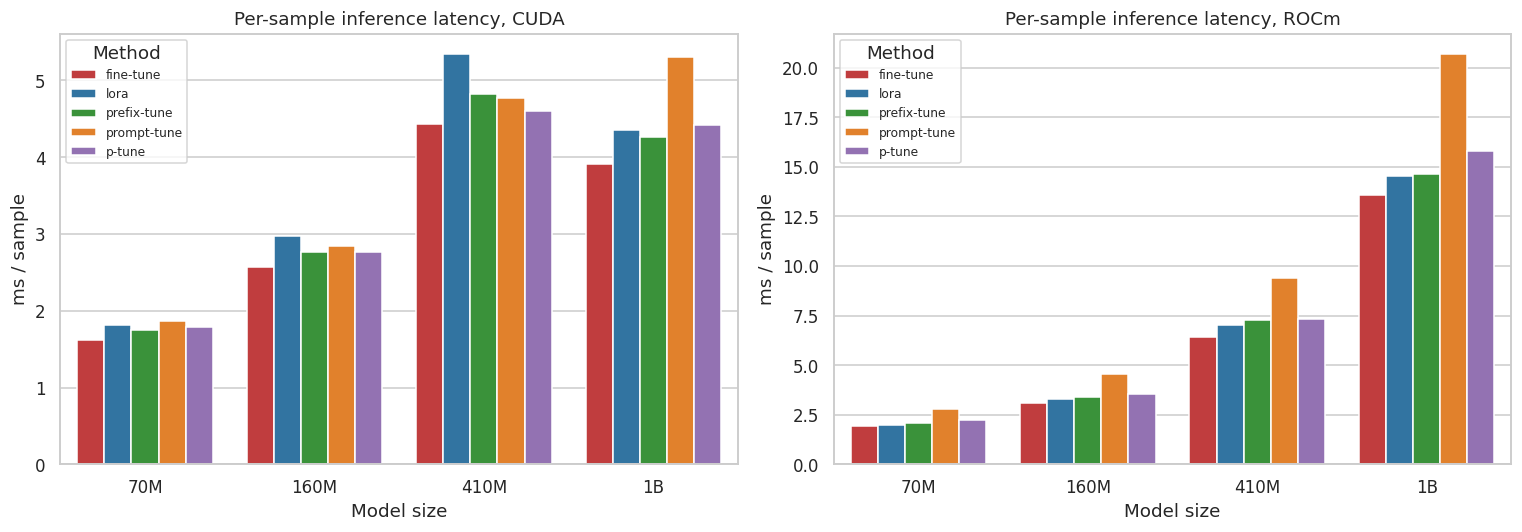

In [106]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, hw in zip(axes, ["CUDA", "ROCm"]):
    d = df[df["hardware"] == hw]
    sns.barplot(
        data=d,
        x="model_short",
        y="inf_latency_ms",
        hue="method",
        palette=METHOD_PALETTE,
        ax=ax,
    )
    ax.set_title(f"Per-sample inference latency, {hw}")
    ax.set_ylabel("ms / sample")
    ax.set_xlabel("Model size")
    ax.legend(title="Method", fontsize=8)
plt.tight_layout()
plt.show()

## 15. Summary table

One row per run with all metrics rounded for the report. We also export this to `ptperf-summary.csv`.

In [107]:
summary = df[
    [
        "hardware",
        "model_short",
        "method",
        "trainable_pct",
        "vram_mb",
        "vram_reserved_mb",
        "train_runtime",
        "train_samples_per_second",
        "flops_t",
        "train_loss",
        "inference_loss",
        "inference_samples_per_second",
        "inf_latency_ms",
        "grad_ckpt",
    ]
].copy()
summary["trainable_pct"] = summary["trainable_pct"].round(3)
summary["vram_mb"] = summary["vram_mb"].round(0).astype(int)
summary["vram_reserved_mb"] = summary["vram_reserved_mb"].round(0).astype(int)
summary["train_runtime"] = summary["train_runtime"].round(1)
summary["train_samples_per_second"] = summary["train_samples_per_second"].round(1)
summary["flops_t"] = summary["flops_t"].round(1)
summary["train_loss"] = summary["train_loss"].round(2)
summary["inference_loss"] = summary["inference_loss"].round(2)
summary["inference_samples_per_second"] = summary["inference_samples_per_second"].round(
    1
)
summary["inf_latency_ms"] = summary["inf_latency_ms"].round(2)
summary = summary.sort_values(["hardware", "model_short", "method"]).reset_index(
    drop=True
)
summary

,hardware,model_short,method,trainable_pct,vram_mb,vram_reserved_mb,train_runtime,train_samples_per_second,flops_t,train_loss,inference_loss,inference_samples_per_second,inf_latency_ms,grad_ckpt
0,CUDA,70M,fine-tune,100.000,4891,12324,35.2,233.0,494.5,5.86,5.76,615.4,1.63,False
1,CUDA,70M,lora,0.278,4368,12122,28.9,283.1,496.6,6.11,6.07,552.7,1.81,False
2,CUDA,70M,prefix-tune,0.865,4279,12092,25.0,327.3,494.5,8.18,8.21,571.5,1.75,False
3,CUDA,70M,prompt-tune,0.073,4928,14140,27.1,301.9,494.5,6.89,7.02,536.7,1.86,False
4,CUDA,70M,p-tune,1.129,4562,12818,26.9,304.5,494.5,6.65,6.68,558.6,1.79,False
5,CUDA,160M,fine-tune,100.000,6882,13550,64.4,127.2,1369.1,4.71,4.52,389.7,2.57,False
6,CUDA,160M,lora,0.362,5706,13102,51.9,157.9,1375.6,4.33,4.35,336.3,2.97,False
7,CUDA,160M,prefix-tune,1.123,5433,12926,43.0,190.4,1369.1,7.81,7.83,362.4,2.76,False
8,CUDA,160M,prompt-tune,0.047,6358,15152,44.5,184.2,1369.1,4.89,5.02,351.7,2.84,False
9,CUDA,160M,p-tune,0.658,5908,13816,43.7,187.3,1369.1,5.35,5.48,361.9,2.76,False


In [108]:
summary.to_csv("ptperf-summary.csv", index=False)
print("Saved ptperf-summary.csv")

Saved ptperf-summary.csv


## 16. Poster exports (high-resolution PNG)

Re-generates the key figures with larger fonts, fixed legend positions, and saves them as 200 dpi PNGs ready to drop into the poster. Run this section after the rest of the notebook has executed.

In [51]:
import matplotlib as mpl

# Poster-specific style settings
POSTER_DPI = 200

POSTER_RC = {
    "font.size": 13,
    "axes.titlesize": 14,
    "axes.labelsize": 13,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.fontsize": 11,
    "figure.dpi": 110,
    "savefig.dpi": POSTER_DPI,
    "savefig.bbox": "tight",
    "savefig.pad_inches": 0.2,
}
print(
    "Poster styling defined. Each export cell wraps itself in"
    " `with mpl.rc_context(POSTER_RC):`."
)

Poster styling defined. Each export cell wraps itself in `with mpl.rc_context(POSTER_RC):`.


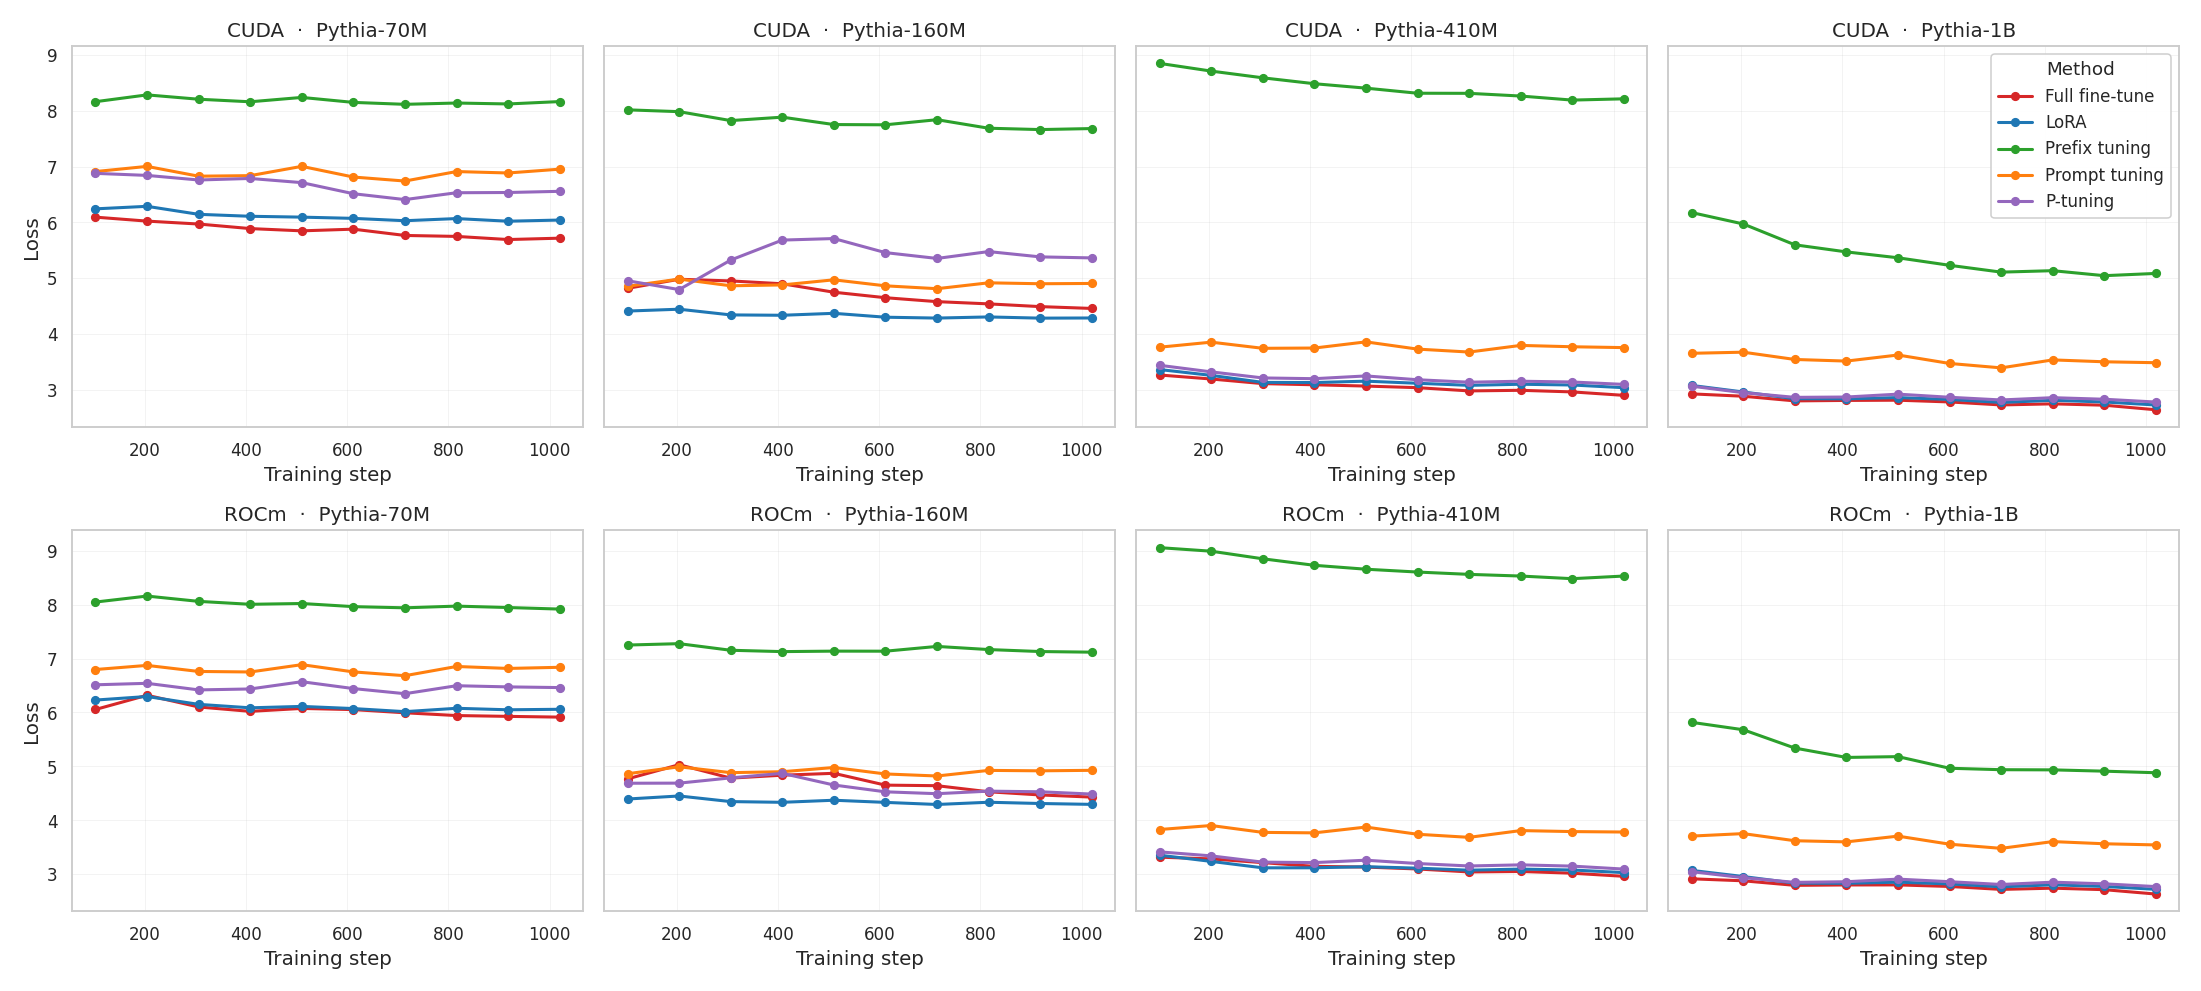

Saved poster_loss_curves.png (with pretty method names in legend)


In [52]:
# 1) Loss curves (2x4 grid) — for poster
with mpl.rc_context(POSTER_RC):
    fig, axes = plt.subplots(2, 4, figsize=(20, 9), sharey="row")
    for row, hw in enumerate(["CUDA", "ROCm"]):
        for col, ms in enumerate(["70M", "160M", "410M", "1B"]):
            ax = axes[row, col]
            d = curves[(curves["hardware"] == hw) & (curves["model_short"] == ms)]
            for method, color in METHOD_PALETTE.items():
                dm = d[d["method"] == method].sort_values("step")
                if not dm.empty:
                    ax.plot(
                        dm["step"],
                        dm["loss"],
                        "-o",
                        color=color,
                        label=METHOD_LABELS.get(method, method),
                        markersize=5,
                        linewidth=2,
                    )
            ax.set_title(f"{hw}  \u00b7  Pythia-{ms}", fontsize=13)
            ax.set_xlabel("Training step")
            ax.set_ylabel("Loss" if col == 0 else "")
            ax.grid(alpha=0.3, linewidth=0.5)
            ax.set_axisbelow(True)
    axes[0, 3].legend(title="Method", loc="upper right", framealpha=0.95)
    plt.tight_layout()
    plt.savefig("poster_loss_curves.png", transparent=True)
    plt.show()
print("Saved poster_loss_curves.png (with pretty method names in legend)")

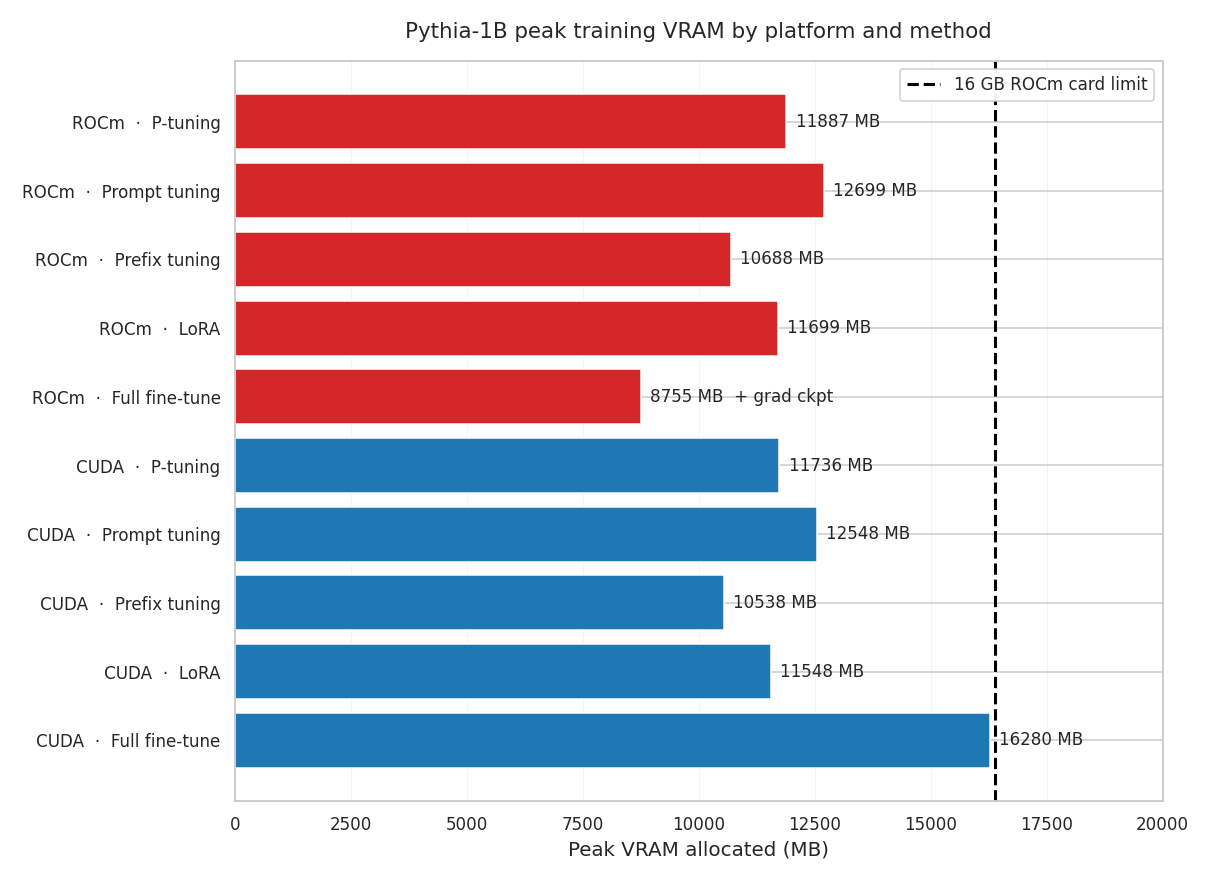

Saved poster_1b_ceiling.png (transparent background, pretty method names)


In [53]:
# 2) 1B memory ceiling — for poster
with mpl.rc_context(POSTER_RC):
    fig, ax = plt.subplots(figsize=(11, 8))
    d_1b = df[df["model_short"] == "1B"].copy().sort_values(["hardware", "method"])
    d_1b["method_pretty"] = (
        d_1b["method"].astype(str).map(METHOD_LABELS).fillna(d_1b["method"].astype(str))
    )
    d_1b["label"] = d_1b["hardware"].astype(str) + "  \u00b7  " + d_1b["method_pretty"]
    d_1b["note"] = d_1b.apply(
        lambda r: "  + grad ckpt" if r["grad_ckpt"] else "", axis=1
    )
    colors = ["#1f77b4" if h == "CUDA" else "#d62728" for h in d_1b["hardware"]]
    y = range(len(d_1b))
    ax.barh(y, d_1b["vram_mb"], color=colors)
    ax.set_yticks(y)
    ax.set_yticklabels(d_1b["label"])
    ax.set_xlim(0, 20000)
    for i, (mb, note) in enumerate(zip(d_1b["vram_mb"], d_1b["note"])):
        ax.text(mb + 200, i, f"{mb:.0f} MB{note}", va="center", fontsize=11)
    ax.axvline(
        16384, color="black", linestyle="--", linewidth=2, label="16 GB ROCm card limit"
    )
    ax.set_xlabel("Peak VRAM allocated (MB)")
    ax.set_title("Pythia-1B peak training VRAM by platform and method", pad=15)
    ax.legend(loc="upper right", framealpha=0.95)
    ax.grid(axis="x", alpha=0.3, linewidth=0.5)
    ax.set_axisbelow(True)
    plt.tight_layout()
    plt.savefig("poster_1b_ceiling.png", transparent=True)
    plt.show()
print("Saved poster_1b_ceiling.png (transparent background, pretty method names)")

In [ ]:
# 3) VRAM savings vs full fine-tune (CUDA only — ROCm has the 1B
#    grad-ckpt anomaly) — for poster
with mpl.rc_context(POSTER_RC):
    sav = savings_vs_ft(df)
    sav_peft = sav[(sav["method"] != "fine-tune") & (sav["hardware"] == "CUDA")]
    fig, ax = plt.subplots(figsize=(13, 6.5))
    sns.barplot(
        data=sav_peft,
        x="model_short",
        y="vram_saving_pct",
        hue="method",
        palette=METHOD_PALETTE,
        ax=ax,
        order=["70M", "160M", "410M", "1B"],
        errorbar=None,
    )
    ax.axhline(0, color="black", linewidth=0.7)
    ax.set_title("VRAM savings vs full fine-tune (CUDA, all PEFT methods)", pad=12)
    ax.set_ylabel("VRAM reduction (%)")
    ax.set_xlabel("Model size")
    ax.grid(axis="y", alpha=0.3, linewidth=0.5)
    ax.set_axisbelow(True)
    for container in ax.containers:
        ax.bar_label(container, fmt="%.0f%%", padding=3, fontsize=10)
    # Pretty method names + legend below the chart
    handles, labels = ax.get_legend_handles_labels()
    labels = [METHOD_LABELS.get(lbl, lbl) for lbl in labels]
    ax.legend(
        handles,
        labels,
        loc="lower center",
        bbox_to_anchor=(0.5, -0.28),
        ncol=len(handles),
        frameon=False,
        fontsize=12,
        title=None,
    )
    plt.tight_layout()
    plt.savefig("poster_vram_savings.png", transparent=True)
    plt.show()
print("Saved poster_vram_savings.png (CUDA only, all bar labels, legend below chart)")

In [ ]:
# 4) Training speedup vs full fine-tune (CUDA only — ROCm 1B FT
#    used grad ckpt) — for poster
with mpl.rc_context(POSTER_RC):
    spd = speedup(df)
    spd_peft = spd[(spd["method"] != "fine-tune") & (spd["hardware"] == "CUDA")]
    fig, ax = plt.subplots(figsize=(13, 6.5))
    sns.barplot(
        data=spd_peft,
        x="model_short",
        y="speedup",
        hue="method",
        palette=METHOD_PALETTE,
        ax=ax,
        order=["70M", "160M", "410M", "1B"],
        errorbar=None,
    )
    ax.axhline(
        1.0, color="black", linewidth=1, linestyle="--", label="Full FT baseline"
    )
    ax.set_title("Training speedup vs full fine-tune (CUDA, higher = faster)", pad=12)
    ax.set_ylabel("Speedup (\u00d7)")
    ax.set_xlabel("Model size")
    ax.grid(axis="y", alpha=0.3, linewidth=0.5)
    ax.set_axisbelow(True)
    # Label every bar (no [:-1] this time — that was wrong;
    # it was hiding the LoRA labels)
    for container in ax.containers:
        ax.bar_label(container, fmt="%.1f\u00d7", padding=3, fontsize=10)
    # Pretty method names + legend below the chart (include the baseline line)
    handles, labels = ax.get_legend_handles_labels()
    labels = [METHOD_LABELS.get(lbl, lbl) for lbl in labels]
    ax.legend(
        handles,
        labels,
        loc="lower center",
        bbox_to_anchor=(0.5, -0.28),
        ncol=len(handles),
        frameon=False,
        fontsize=12,
        title=None,
    )
    plt.tight_layout()
    plt.savefig("poster_speedup.png", transparent=True)
    plt.show()
print(
    "Saved poster_speedup.png (CUDA only, ALL bar labels including"
    " LoRA, legend below chart)"
)

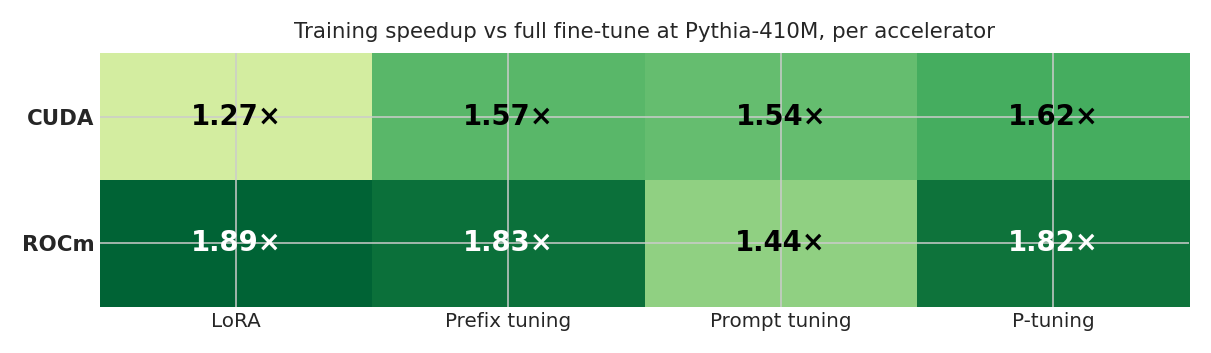

Saved poster_accelerator_speedup.png (Pythia-410M only)
410M chosen because it runs without gradient checkpointing on BOTH platforms, making the cross-platform comparison fair.


In [54]:
# 7) Per-accelerator speedup at Pythia-410M — for poster
# 410M is the cleanest cross-platform comparison: both platforms ran without gradient
# checkpointing, so the speedups are directly comparable.
with mpl.rc_context(POSTER_RC):
    spd = speedup(df)
    spd_410 = spd[
        (spd["method"] != "fine-tune") & (spd["model_short"] == "410M")
    ].copy()
    tbl = spd_410.pivot_table(
        index="hardware", columns="method", values="speedup", observed=True
    )
    tbl = tbl[["lora", "prefix-tune", "prompt-tune", "p-tune"]]
    tbl.columns = [METHOD_LABELS[c] for c in tbl.columns]
    tbl.index.name = None

    fig, ax = plt.subplots(figsize=(11, 3.2))
    im = ax.imshow(tbl.values, cmap="YlGn", vmin=1.0, vmax=2.0, aspect="auto")
    ax.set_xticks(range(len(tbl.columns)))
    ax.set_xticklabels(tbl.columns, fontsize=13)
    ax.set_yticks(range(len(tbl.index)))
    ax.set_yticklabels(tbl.index, fontsize=14, fontweight="bold")
    for r in range(tbl.shape[0]):
        for col in range(tbl.shape[1]):
            v = tbl.values[r, col]
            ax.text(
                col,
                r,
                f"{v:.2f}\u00d7",
                ha="center",
                va="center",
                fontsize=18,
                fontweight="bold",
                color="black" if v < 1.7 else "white",
            )
    ax.set_title(
        "Training speedup vs full fine-tune at Pythia-410M, per accelerator", pad=10
    )
    ax.tick_params(axis="both", which="both", length=0)
    for spine in ax.spines.values():
        spine.set_visible(False)
    plt.tight_layout()
    plt.savefig("poster_accelerator_speedup.png", transparent=True)
    plt.show()
print("Saved poster_accelerator_speedup.png (Pythia-410M only)")
print(
    "410M chosen because it runs without gradient checkpointing on"
    " BOTH platforms, making the cross-platform comparison fair."
)

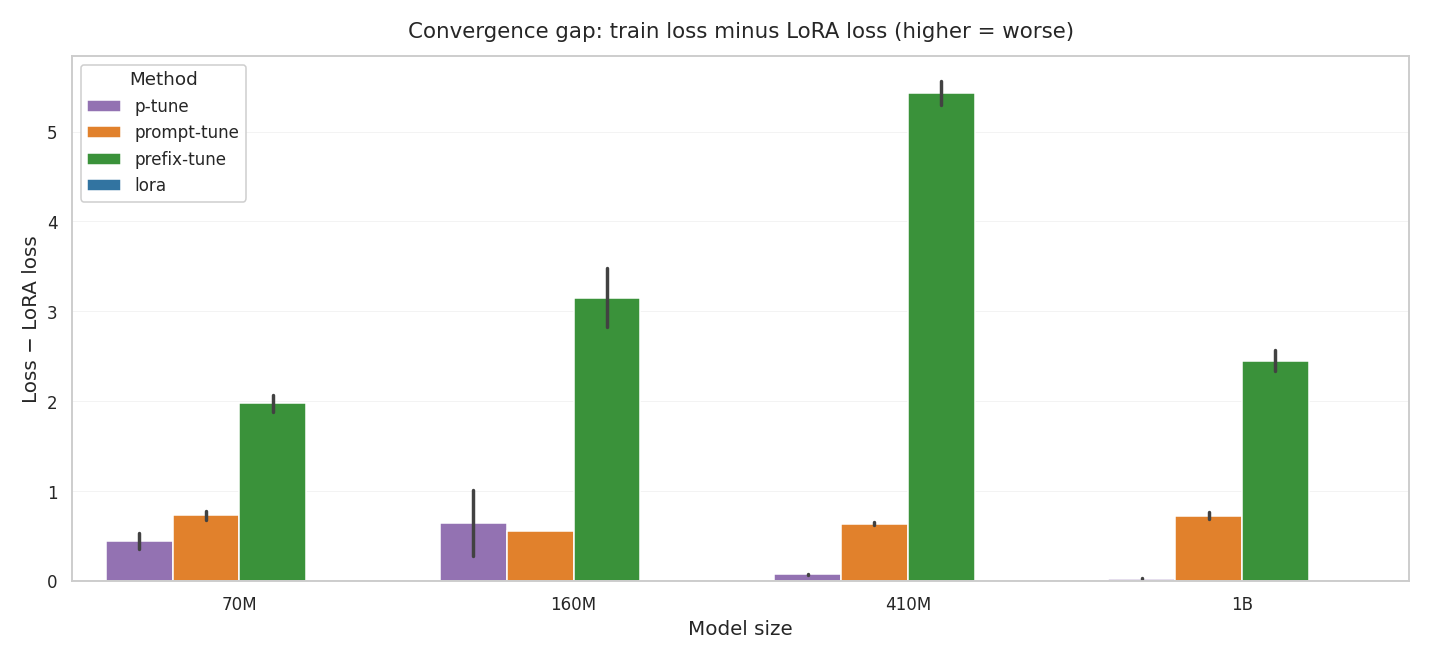

Saved poster_convergence_gap.png


In [129]:
# 5) Convergence gap vs LoRA (prefix-tune failure) — for poster
with mpl.rc_context(POSTER_RC):
    gaps = []
    for (hw, ms), g in df.groupby(["hardware", "model_short"], observed=False):
        lora_row = g[g["method"] == "lora"]
        if lora_row.empty:
            continue
        lora_loss = lora_row["train_loss"].iloc[0]
        for _, row in g.iterrows():
            if row["method"] == "fine-tune":
                continue
            gaps.append(
                {
                    "hardware": hw,
                    "model_short": ms,
                    "method": row["method"],
                    "loss_gap_vs_lora": row["train_loss"] - lora_loss,
                }
            )
    gaps_df = pd.DataFrame(gaps)
    fig, ax = plt.subplots(figsize=(13, 6))
    sns.barplot(
        data=gaps_df,
        x="model_short",
        y="loss_gap_vs_lora",
        hue="method",
        palette=METHOD_PALETTE,
        ax=ax,
        order=["70M", "160M", "410M", "1B"],
    )
    ax.axhline(0, color="black", linewidth=0.7)
    ax.set_title("Convergence gap: train loss minus LoRA loss (higher = worse)", pad=12)
    ax.set_ylabel("Loss - LoRA loss")
    ax.set_xlabel("Model size")
    ax.legend(title="Method", loc="upper left", framealpha=0.95)
    ax.grid(axis="y", alpha=0.3, linewidth=0.5)
    ax.set_axisbelow(True)
    plt.tight_layout()
    plt.savefig("poster_convergence_gap.png", transparent=True)
    plt.show()
print("Saved poster_convergence_gap.png")

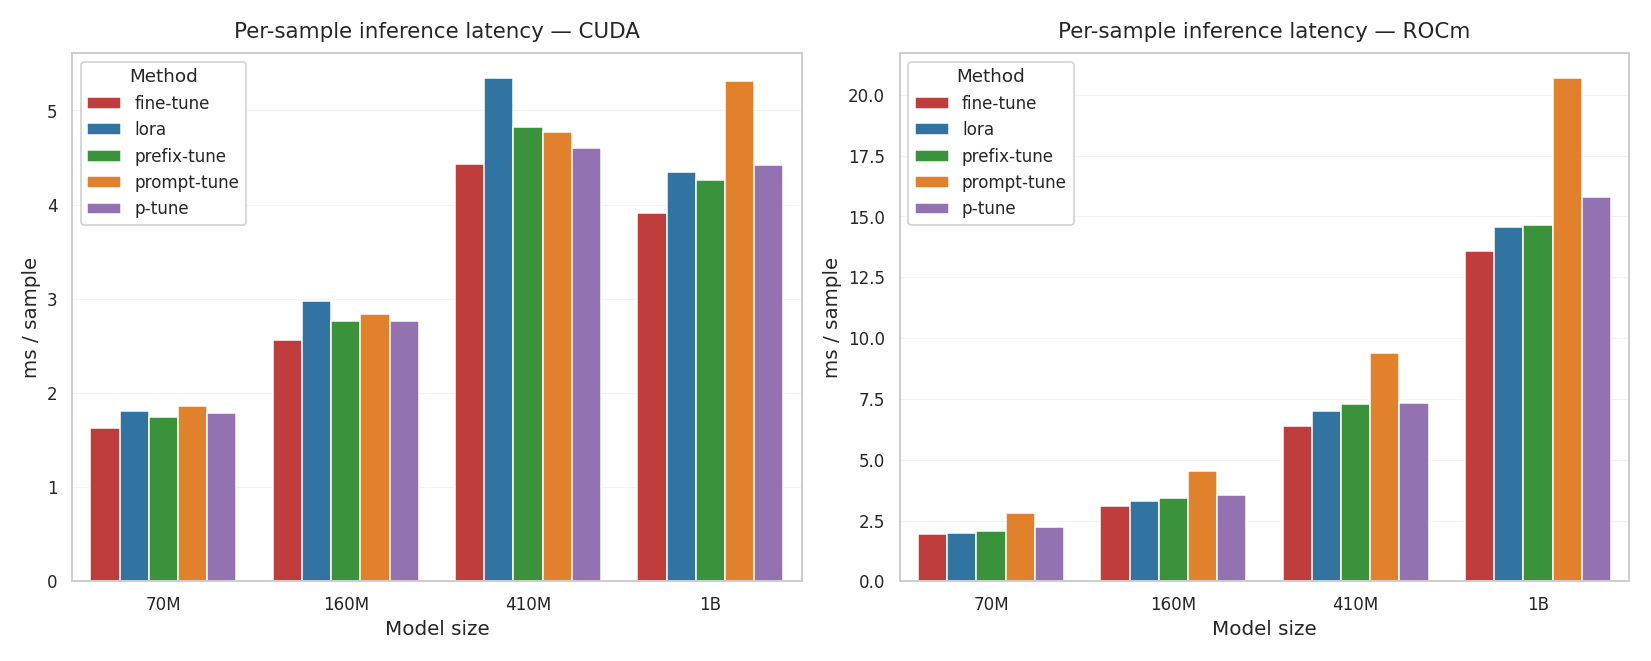

Saved poster_inference_latency.png


In [130]:
# 6) Inference latency per sample — for poster
with mpl.rc_context(POSTER_RC):
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    for ax, hw in zip(axes, ["CUDA", "ROCm"]):
        d = df[df["hardware"] == hw]
        sns.barplot(
            data=d,
            x="model_short",
            y="inf_latency_ms",
            hue="method",
            palette=METHOD_PALETTE,
            ax=ax,
        )
        ax.set_title(f"Per-sample inference latency — {hw}", pad=10)
        ax.set_ylabel("ms / sample")
        ax.set_xlabel("Model size")
        ax.legend(title="Method", loc="upper left", framealpha=0.95)
        ax.grid(axis="y", alpha=0.3, linewidth=0.5)
        ax.set_axisbelow(True)
    plt.tight_layout()
    plt.savefig("poster_inference_latency.png", transparent=True)
    plt.show()
print("Saved poster_inference_latency.png")